The flow of the case study is as below:

1. Importing Libraries and setting up the environment
2. Defining the problem statement
3. Data Preparation
4. Train-Test Split
5. Descriptive Statistics and Data Exploration
6. Data Preprocessing
6.1: Feature Engineering
6.2: Missing Value Treatment
6.3: Dummy Variable
6.4: Other Imputation
6.5: Log Transformation
6.6: Feature Selection
6.7: Feature Scaling
7. Conclusion
8. Importing Trainset and Testset.



# **1. Importing libraries**

In [128]:
# Import necessary libraries
# Base Libraries
import re
import time
import numpy as np
import pandas as pd
# Library for Google Colab
from google.colab import drive

# For data visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(palette="Set2")
#magic function for displaying plot in the notebook
%matplotlib inline
# silence warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
# For Data Preprocessing and Cleaning
# Handle non-convergence alerts
from sklearn.exceptions import ConvergenceWarning
# Stratified train/test splits in scikit-learn
from sklearn.model_selection import StratifiedShuffleSplit
# Use train_test_split to split the data into a training and a test set
from sklearn.model_selection import train_test_split
"""Imports `OneHotEncoder` from scikit-learn for converting categorical variables
into a one-hot numerical representation"""
from sklearn.preprocessing import OneHotEncoder
# Imports scikit-learn classes for custom transformers
from sklearn.base import TransformerMixin, BaseEstimator
# Enable the experimental IterativeImputer module in scikit-learn
from sklearn.experimental import enable_iterative_imputer
# Import IterativeImputer and SimpleImputer classes from scikit-learn for imputing missing values
from sklearn.impute import IterativeImputer, SimpleImputer
# Import KNN Imputer class from scikit-learn for KNN Imputation
from sklearn.impute import KNNImputer
# Import the OutlierMixin class from the sklearn.base module
# for custom outlier detection classes
from sklearn.base import OutlierMixin
# Import IsolationForest to detect outliers
from sklearn.ensemble import IsolationForest
# Import SelectKBest from sklearn.feature_selection module to select the top k features
from sklearn.feature_selection import SelectKBest
# Import the f_classif function from sklearn.feature_selection module
# Univariate feature selection technique used specifically for classification tasks
from sklearn.feature_selection import f_classif
# Import StandardScaler from sklearn.preprocessing module for standardize features
from sklearn.preprocessing import StandardScaler

In [129]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [130]:
import warnings
warnings.filterwarnings("ignore")


# **2. Business Objective**

Our goal is to develop a predictive model that evaluates the potential severity of car accidents involving insured drivers based on driver and vehicle characteristics. This model will enable the insurance company to more accurately price premiums and mitigate risks by identifying drivers who are more likely to be involved in severe accidents. By leveraging this model, the company can enhance its risk management strategies, improve financial stability, and provide better pricing fairness for policyholders.

In [131]:
# Load datasets
vehicles = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/bigdata/Vehicles_Dataset.csv')
casualties = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/bigdata/Casualties_Dataset.csv')
collisions = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/bigdata/Collisions_Dataset.csv')


Determining the type of Machine Learning
Based on the problem statement you can understand that we need to create a supervised ML classification model, as the target variable is categorical.

Reading the data:

This is one of the most important steps in machine learning.

The data has three file "Vehicles_Dataset.csv". "Casualties_Dataset.csv" and "Collisions_Dataset.csv", containing historical information about the accidents.Goal is to predict the accident severity so as to enable the insurance companies to identify severity of accidents taht were claimed.

# **3. DATA PREPARATION**

3.1: Uploading 1st Dataset

In [132]:
# Inspect the first few rows of  dataframe to understand the structure
collisions.shape
collisions.info()
collisions.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106004 entries, 0 to 106003
Data columns (total 36 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   accident_index                               106004 non-null  object 
 1   accident_year                                106004 non-null  int64  
 2   accident_reference                           106004 non-null  object 
 3   location_easting_osgr                        105982 non-null  float64
 4   location_northing_osgr                       105982 non-null  float64
 5   longitude                                    105982 non-null  float64
 6   latitude                                     105982 non-null  float64
 7   police_force                                 106004 non-null  int64  
 8   accident_severity                            106004 non-null  int64  
 9   number_of_vehicles                           106004 non-nul

,accident_index,accident_year,accident_reference,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location
0,2022010352073,2022,10352073,525199.0,177928.0,-0.198224,51.486454,1,3,2,...,0,4,1,1,0,0,1,1,2,E01001883
1,2022010352573,2022,10352573,546214.0,179866.0,0.105042,51.498830,1,3,2,...,4,4,1,1,0,0,2,1,2,E01033745
2,2022010352575,2022,10352575,551119.0,174789.0,0.173482,51.451924,1,3,2,...,0,4,1,1,0,0,1,1,2,E01000378
3,2022010352578,2022,10352578,528889.0,192230.0,-0.139873,51.614153,1,3,2,...,0,4,1,1,0,0,1,1,2,E01001529
4,2022010352580,2022,10352580,539773.0,190404.0,0.016495,51.595151,1,3,4,...,0,4,1,1,0,0,1,1,2,E01003673


Uploading 2nd Dataset

In [133]:
# Inspect the first few rows of  dataframe to understand the structure
vehicles.shape
vehicles.info()
vehicles.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193545 entries, 0 to 193544
Data columns (total 28 columns):
 #   Column                            Non-Null Count   Dtype 
---  ------                            --------------   ----- 
 0   accident_index                    193545 non-null  object
 1   accident_year                     193545 non-null  int64 
 2   accident_reference                193545 non-null  object
 3   vehicle_reference                 193545 non-null  int64 
 4   vehicle_type                      193545 non-null  int64 
 5   towing_and_articulation           193545 non-null  int64 
 6   vehicle_manoeuvre                 193545 non-null  int64 
 7   vehicle_direction_from            193545 non-null  int64 
 8   vehicle_direction_to              193545 non-null  int64 
 9   vehicle_location_restricted_lane  193545 non-null  int64 
 10  junction_location                 193545 non-null  int64 
 11  skidding_and_overturning          193545 non-null  int64 
 12  hi

,accident_index,accident_year,accident_reference,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane,...,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,driver_home_area_type,lsoa_of_driver
0,2022010352073,2022,10352073,1,19,0,9,3,8,0,...,1,48,8,1461,2,4,RENAULT KANGOO,7,1,E01002687
1,2022010352073,2022,10352073,2,3,0,18,1,5,0,...,1,17,4,125,1,1,HONDA FSH125,1,1,E01001364
2,2022010352573,2022,10352573,1,9,0,18,7,3,0,...,2,42,7,-1,-1,-1,-1,5,1,E01000338
3,2022010352573,2022,10352573,2,9,0,13,7,3,0,...,3,-1,-1,-1,-1,-1,-1,-1,-1,-1
4,2022010352575,2022,10352575,1,9,0,18,4,8,0,...,1,20,4,1896,2,15,VOLKSWAGEN GOLF,8,1,E01000390


Uploading 3rd dataset

In [134]:
# Inspect the first few rows of  dataframe to understand the structure
casualties.shape
casualties.info()
casualties.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135480 entries, 0 to 135479
Data columns (total 19 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   accident_index                      135480 non-null  object
 1   accident_year                       135480 non-null  int64 
 2   accident_reference                  135480 non-null  object
 3   vehicle_reference                   135480 non-null  int64 
 4   casualty_reference                  135480 non-null  int64 
 5   casualty_class                      135480 non-null  int64 
 6   sex_of_casualty                     135480 non-null  int64 
 7   age_of_casualty                     135480 non-null  int64 
 8   age_band_of_casualty                135480 non-null  int64 
 9   casualty_severity                   135480 non-null  int64 
 10  pedestrian_location                 135480 non-null  int64 
 11  pedestrian_movement                 135

,accident_index,accident_year,accident_reference,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile,lsoa_of_casualty
0,2022010352073,2022,10352073,2,1,1,1,17,4,3,0,0,0,0,0,3,1,1,E01001364
1,2022010352573,2022,10352573,1,1,1,2,42,7,3,0,0,0,0,0,9,1,5,E01000338
2,2022010352575,2022,10352575,1,1,1,1,20,4,3,0,0,0,0,0,9,1,8,E01000390
3,2022010352578,2022,10352578,1,1,1,1,46,8,3,0,0,0,0,0,9,1,3,E01004666
4,2022010352578,2022,10352578,1,2,2,1,45,7,3,0,0,1,0,0,9,1,3,E01004666


### **3.2: Selecting relevant columns from different datasets is a crucial step**

This involves identifying which variables (or columns) from the data might have a significant influence on the target variable, which in this case is "accident severity".

In [135]:
# Select relevant columns from each dataset

collisions_relevant = collisions[['accident_reference','accident_severity','number_of_vehicles','number_of_casualties','date','day_of_week','time', 'speed_limit', 'road_surface_conditions']]
vehicles_relevant = vehicles[['accident_reference','vehicle_manoeuvre', 'sex_of_driver', 'age_of_driver','age_of_vehicle' ,'driver_home_area_type']]
casualties_relevant = casualties[['accident_reference', 'casualty_severity', 'sex_of_casualty', 'age_of_casualty','pedestrian_location','car_passenger', 'casualty_home_area_type']]



**3.3: Handling unknown data in the dataset by assigning them as NaN**

Handling Collision Dataframe: -1 in the dataframe was converted to NaN as this indicates that the value was unknown during the data gathering process.

In [136]:
# Print the columns which contain the value "-1" in the  "collisions_relevant" dataframe
print("Columns that contain the value '-1':")
print(collisions_relevant.columns[(collisions_relevant == -1).any()])


Columns that contain the value '-1':
Index(['road_surface_conditions'], dtype='object')


In [137]:
# Columns needed to replace '-1' with NaN in the  "collisions_relevant" dataframe
collisioncolumns1_replace = [
   'road_surface_conditions'

]
# Replace "-1" with np.NaN
collisions_relevant.loc[:,collisioncolumns1_replace] = collisions_relevant.loc[:,collisioncolumns1_replace].replace(-1, np.NaN)


The variables with value 9 was replaced by NaN as it was unknown during the data collection, except for Junction Detail, were 9 signifies- Other Junction.

In [138]:
# Print the columns which contain the value "9" in the "collision_relevant_df" dataframe
print("Columns that contain the value '9':")
print(collisions_relevant.columns[(collisions_relevant == 9).any()])


Columns that contain the value '9':
Index(['number_of_vehicles', 'number_of_casualties',
       'road_surface_conditions'],
      dtype='object')


In [139]:
# Exceptional column: 'junction_detail' : 9 - Other junction

# Columns needed to replace '9' with NaN in the  "collisions_relevant" dataframe
collisioncolumns_replace = [
 'number_of_vehicles', 'number_of_casualties',
        'road_surface_conditions'

]
# Replace "9" with np.NaN
collisions_relevant.loc[:,collisioncolumns_replace] = collisions_relevant.loc[:,collisioncolumns_replace].replace(9, np.NaN)

No values with 99 was detected, so no handling here is performed.

In [140]:
# Print the columns which contain the value "99" in the "collisions_relevant" dataframe
print("Columns that contain the value '99':")
print(collisions_relevant.columns[(collisions_relevant == 99).any()])

Columns that contain the value '99':
Index([], dtype='object')


Handling vehicles dataframe, -1 in the dataframe was converted to NaN as this indicates that the value was unknown during the data gathering process.

In [141]:
# Print the columns which contain the value "-1" in the  "vehicles_relevant" dataframe
print("Columns that contain the value '-1':")
print(vehicles_relevant.columns[(vehicles_relevant == -1).any()])


Columns that contain the value '-1':
Index(['vehicle_manoeuvre', 'age_of_driver', 'age_of_vehicle',
       'driver_home_area_type'],
      dtype='object')


In [142]:
# Columns needed to replace '-1' with NaN in the  "vehicles_relevant" dataframe
vehicles_casualtiescolumns_replace = [ 'vehicle_manoeuvre',
       'age_of_driver',
        'age_of_vehicle', 'driver_home_area_type']
# Replace "-1" with np.NaN
vehicles_relevant.loc[:,vehicles_casualtiescolumns_replace] = vehicles_relevant.loc[:,vehicles_casualtiescolumns_replace].replace(-1, np.NaN)

The variables with value 9 was replaced by NaN as it was unknown during the data collection, The columns with 9 are relevant, hence were not replaced by Nan.

In [143]:
# Print the columns which contain the value "9" in the  "vehicles_relevant"dataframe
print("Columns that contain the value '9':")
print(vehicles_relevant.columns[(vehicles_relevant == 9).any()])

Columns that contain the value '9':
Index(['vehicle_manoeuvre', 'age_of_driver', 'age_of_vehicle'], dtype='object')


The variables with value 99 were extracted, and in column vehicle_manoeuvre it was replaced by NaN as it was unknown during the data collection.

In [144]:
# Print the columns which contain the value "99" in the  "vehicles_relevant" dataframe
print("Columns that contain the value '99':")
print(vehicles_relevant.columns[(vehicles_relevant == 99).any()])

Columns that contain the value '99':
Index(['vehicle_manoeuvre', 'age_of_driver', 'age_of_vehicle'], dtype='object')


In [145]:
# Columns needed to replace '99' with NaN in the "vehicles_relevant" dataframe
vehiclecolumnsnew_replace = [ 'vehicle_manoeuvre']
# Replace 99 with np.NaN
vehicles_relevant.loc[:, vehiclecolumnsnew_replace] = vehicles_relevant.loc[:, vehiclecolumnsnew_replace].replace(99, np.NaN)

In [146]:
# In the column "sex_of_driver", value 3 represents unknown data
# Replace '3' with np.NaN in the "sex_of_driver" column
vehicles_relevant.loc[:,'sex_of_driver'] = vehicles_relevant.loc[:,'sex_of_driver'].replace(3, np.NaN)

Handling casualties data frame :  The variables with value -1 was replaced by NaN, as this variables were unknown during the data collection.

In [147]:
# Print the columns which contain the value "-1" in the "casualties" dataframe
print("Columns that contain the value '-1':")
print(casualties_relevant.columns[(casualties_relevant == -1).any()])

Columns that contain the value '-1':
Index(['sex_of_casualty', 'age_of_casualty', 'pedestrian_location',
       'car_passenger', 'casualty_home_area_type'],
      dtype='object')


In [148]:
# Columns needed to replace '-1' with NaN in the "casualty_df" dataframe
casualtycolumns1_replace = [
 'sex_of_casualty', 'age_of_casualty', 'pedestrian_location',
       'car_passenger',
        'casualty_home_area_type']
# Replace -1 with np.NaN
casualties_relevant.loc[:,casualtycolumns1_replace] = casualties_relevant.loc[:,casualtycolumns1_replace].replace(-1, np.NaN)

In [149]:
# Print the columns which contain the value "9" in the "casualty_df" dataframe
print("Columns that contain the value '9':")
print(casualties_relevant.columns[(casualties_relevant == 9).any()])

Columns that contain the value '9':
Index(['sex_of_casualty', 'age_of_casualty', 'pedestrian_location',
       'car_passenger'],
      dtype='object')


In [150]:
# Exceptional columns:
# pedestrian_location = 9 (In carriageway, not crossing)
# casualty_type = 9 (Car occupant)
# Columns needed to replace '9' with NaN in the "casualty_df" dataframe
casualtycolumns2_replace = ['sex_of_casualty',
 'car_passenger',
]
# Replace 9 with np.NaN
casualties_relevant.loc[:,casualtycolumns2_replace] = casualties_relevant.loc[:,casualtycolumns2_replace].replace(9, np.NaN)

In [151]:
# Print the columns which contain the value "99" in the "casualty_df" dataframe
print("Columns that contain the value '99':")
print(casualties_relevant.columns[(casualties_relevant == 99).any()])


Columns that contain the value '99':
Index(['age_of_casualty'], dtype='object')


Dataframe copy was created as it is crucial for data integrity, especially when performing transformations, cleaning, or analysis

In [152]:
vehicles_relevant = vehicles_relevant.copy()
casualties_relevant = casualties_relevant.copy()
collisions_relevant = collisions_relevant.copy()


In [153]:
# Merge vehicles and casualties datasets on 'accident_index' and 'vehicle_reference'
vehicles_casualties = pd.merge(vehicles_relevant, casualties_relevant, on=['accident_reference'], how='inner')

vehicles_casualties.shape


(185597, 12)

## **3.4: MERGING OF DATA**


The dataset merging for casualty, collision, and vehicle datasets is to create a comprehensive dataset that integrates information from all three sources.

In [154]:
# Merge vehicles and casualties datasets on 'accident_index' and 'vehicle_reference'
vehicles_casualties = pd.merge(vehicles_relevant, casualties_relevant, on=['accident_reference'], how='inner')

# Merge the result with collisions dataset on 'accident_index'
combined_data = pd.merge(vehicles_casualties, collisions_relevant, on='accident_reference', how='inner')
combined_data


,accident_reference,vehicle_manoeuvre,sex_of_driver,age_of_driver,age_of_vehicle,driver_home_area_type,casualty_severity,sex_of_casualty,age_of_casualty,pedestrian_location,car_passenger,casualty_home_area_type,accident_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,speed_limit,road_surface_conditions
0,10352073,9.0,1.0,48.0,4.0,1.0,3,1.0,17.0,0.0,0.0,1.0,3,2.0,1.0,05/01/2022,4,16:40,30,1.0
1,10352073,18.0,1.0,17.0,1.0,1.0,3,1.0,17.0,0.0,0.0,1.0,3,2.0,1.0,05/01/2022,4,16:40,30,1.0
2,10352573,18.0,2.0,42.0,NaN,1.0,3,2.0,42.0,0.0,0.0,1.0,3,2.0,1.0,01/01/2022,7,01:17,50,1.0
3,10352573,13.0,NaN,NaN,NaN,NaN,3,2.0,42.0,0.0,0.0,1.0,3,2.0,1.0,01/01/2022,7,01:17,50,1.0
4,10352575,18.0,1.0,20.0,15.0,1.0,3,1.0,20.0,0.0,0.0,1.0,3,2.0,1.0,01/01/2022,7,01:15,30,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168879,991162012,18.0,2.0,61.0,3.0,1.0,2,1.0,44.0,0.0,0.0,2.0,2,2.0,1.0,02/04/2022,7,12:50,60,1.0
168880,991162012,18.0,1.0,44.0,1.0,2.0,2,1.0,44.0,0.0,0.0,2.0,2,2.0,1.0,02/04/2022,7,12:50,60,1.0
168881,991162014,18.0,1.0,21.0,13.0,1.0,2,1.0,74.0,5.0,0.0,1.0,2,1.0,1.0,02/04/2022,7,17:04,30,1.0
168882,991162022,15.0,1.0,31.0,NaN,2.0,2,1.0,31.0,0.0,0.0,2.0,2,2.0,1.0,01/04/2022,6,20:15,20,2.0


In [155]:
# Get information about the "accident_info" DataFrame
combined_data.info()
combined_data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168884 entries, 0 to 168883
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   accident_reference       168884 non-null  object 
 1   vehicle_manoeuvre        150514 non-null  float64
 2   sex_of_driver            147277 non-null  float64
 3   age_of_driver            144290 non-null  float64
 4   age_of_vehicle           136148 non-null  float64
 5   driver_home_area_type    136227 non-null  float64
 6   casualty_severity        168884 non-null  int64  
 7   sex_of_casualty          167073 non-null  float64
 8   age_of_casualty          164630 non-null  float64
 9   pedestrian_location      168882 non-null  float64
 10  car_passenger            168073 non-null  float64
 11  casualty_home_area_type  152175 non-null  float64
 12  accident_severity        168884 non-null  int64  
 13  number_of_vehicles       168821 non-null  float64
 14  numb

(168884, 20)

 A subset of 10,000 rows for further analysis is considered for several practical considerations as it allowed for efficient and manageable data handling in our case of working with large datasets

In [156]:
combined_data = combined_data.head(10000)
combined_data

,accident_reference,vehicle_manoeuvre,sex_of_driver,age_of_driver,age_of_vehicle,driver_home_area_type,casualty_severity,sex_of_casualty,age_of_casualty,pedestrian_location,car_passenger,casualty_home_area_type,accident_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,speed_limit,road_surface_conditions
0,10352073,9.0,1.0,48.0,4.0,1.0,3,1.0,17.0,0.0,0.0,1.0,3,2.0,1.0,05/01/2022,4,16:40,30,1.0
1,10352073,18.0,1.0,17.0,1.0,1.0,3,1.0,17.0,0.0,0.0,1.0,3,2.0,1.0,05/01/2022,4,16:40,30,1.0
2,10352573,18.0,2.0,42.0,NaN,1.0,3,2.0,42.0,0.0,0.0,1.0,3,2.0,1.0,01/01/2022,7,01:17,50,1.0
3,10352573,13.0,NaN,NaN,NaN,NaN,3,2.0,42.0,0.0,0.0,1.0,3,2.0,1.0,01/01/2022,7,01:17,50,1.0
4,10352575,18.0,1.0,20.0,15.0,1.0,3,1.0,20.0,0.0,0.0,1.0,3,2.0,1.0,01/01/2022,7,01:15,30,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,10366366,18.0,1.0,41.0,7.0,1.0,3,2.0,28.0,0.0,1.0,1.0,3,2.0,3.0,19/03/2022,7,21:50,20,1.0
9996,10366366,18.0,1.0,41.0,7.0,1.0,3,2.0,28.0,0.0,2.0,NaN,3,2.0,3.0,19/03/2022,7,21:50,20,1.0
9997,10366367,NaN,NaN,NaN,7.0,NaN,3,1.0,15.0,5.0,0.0,1.0,3,1.0,1.0,17/03/2022,5,15:30,30,1.0
9998,10366374,4.0,1.0,48.0,4.0,NaN,2,1.0,58.0,0.0,0.0,1.0,2,3.0,1.0,20/03/2022,1,00:46,20,1.0


In [157]:
# Get the number of rows and columns in the updated dataframe
combined_data.shape

(10000, 20)

This combined_data is used for further preprocessing, imputation and handling.

### **3.5: MAPPING METHOD** TO REPLACE NUMBER WITH STRINGS:

The Mapping was performed on the numerical data variable to facilitate the understanding and visualization of the variable, nan acts as a placeholder here.

In [158]:
# Assuming 'accident_severity' is a column in the original dataset,

# Define a mapping between integers and corresponding severity labels
accidentseverity_mapping = {
 1: 'Fatal',
 2: 'Serious',
 3: 'Slight',
}

# Map the integers in the 'accident_severity' column to their corresponding labels
# using the defined mapping
combined_data.loc[:,'accident_severity'] = combined_data.loc[:,
 'accident_severity'].map(accidentseverity_mapping)

# Examine the result
combined_data["accident_severity"].unique()

array(['Slight', 'Serious', 'Fatal'], dtype=object)

In [159]:
# Define the new mapping where 'fatal' and 'serious' are merged into one category, and 'slight' remains the same
def merge_severity(severity):
    if severity == 'Fatal' or severity == 'Serious':
        return 'Serious_or_Fatal'
    elif severity == 'Slight':
        return 'Slight'
    else:
        return severity  # If there are any other values, return them as is (though there shouldn't be any)

# Apply the merge_severity function to the 'accident_severity' column
combined_data.loc[:,'accident_severity'] = combined_data['accident_severity'].apply(merge_severity)

# Define a new mapping to map 'Serious_or_Fatal' to 1 and 'Slight' to 2
new_severity_mapping = {
    'Serious_or_Fatal': 1,
    'Slight': 2
}

# Map the new severity categories to their corresponding integer labels
combined_data.loc[:,'accident_severity'] = combined_data.loc[:,'accident_severity'].map(new_severity_mapping)
# Ensure accident_severity is a categorical variable with type object
combined_data.loc[:,'accident_severity'] = combined_data.loc[:,'accident_severity'].astype('object')

# Examine the result by printing the unique values in the 'accident_severity' column
print(combined_data["accident_severity"].unique())

[2 1]


In [160]:
# Define a mapping between integers and corresponding driver home area labels
driverhomeareatype_mapping = {
 1: 'Urban area',
 2: 'Small town',
 3: 'Rural'
}
"""Map the integers in the 'driver_home_area_type' column to their corresponding
 labels using the defined mapping"""
combined_data.loc[:,'driver_home_area_type'] = combined_data[
 'driver_home_area_type'].map(driverhomeareatype_mapping)
# Examine the result
combined_data["driver_home_area_type"].unique()

array(['Urban area', nan, 'Small town', 'Rural'], dtype=object)

The nan here represents the unknown values which were not present during data collection.

In [161]:
# Initialize an "vehiclemanoeuvre_mapping" dictionary to map the value of the "vehicle_manoeuvre"
# variable to corresponding labels.
vehiclemanoeuvre_mapping = {
 1: 'Reversing',
 2: 'Parked',
 3: 'Waiting to go - held up',
 4: 'Slowing or stopping',
 5: 'Moving off',
 6: 'U-turn',
 7: 'Turning left',
 8: 'Waiting to turn left',
 9: 'Turning right',
 10: 'Waiting to turn right',
 11: 'Changing lane to left',
 12: 'Changing lane to right',
 13: 'Overtaking moving vehicle - offside',
 14: 'Overtaking static vehicle - offside',
 15: 'Overtaking - nearside',
 16: 'Going ahead left-hand bend',
 17: 'Going ahead right-hand bend',
 18: 'Going ahead other '}
# Map integer values to categorical labels for 'vehicle_manoeuvre' column
combined_data.loc[:,'vehicle_manoeuvre'] = combined_data.loc[:,
 'vehicle_manoeuvre'].map(vehiclemanoeuvre_mapping)
# Examine the result
combined_data['vehicle_manoeuvre'].unique()


array(['Turning right', 'Going ahead other ',
       'Overtaking moving vehicle - offside', 'Slowing or stopping',
       'Going ahead right-hand bend', 'Parked', 'Waiting to go - held up',
       'Waiting to turn left', 'Turning left', 'Overtaking - nearside',
       'Going ahead left-hand bend', 'Moving off', 'U-turn', 'Reversing',
       nan, 'Waiting to turn right',
       'Overtaking static vehicle - offside', 'Changing lane to right',
       'Changing lane to left'], dtype=object)

In [162]:
# Define a mapping between integers and corresponding sex of driver labels
sexofdriver_mapping = {1: 'Male',2: 'Female'}
# Map integer values to categorical labels for 'sex_of_driver' column
combined_data.loc[:,'sex_of_driver'] = combined_data.loc[:,
 'sex_of_driver'].map(sexofdriver_mapping)

# Examine the result
combined_data["sex_of_driver"].unique()

array(['Male', 'Female', nan], dtype=object)

The 'nan' in the sex of driver, represents Unknown value

In [163]:
# Define a mapping between integers and corresponding road surface conditions
road_surface_conditions_mapping = {
 1: 'Dry',
 2: 'Wet or damp',
 3: 'Snow or ice',
 4: 'Frost or ice fog',
 5: 'Flood over 3cm. deep',
 6: 'Oil or Diesel',
 7: 'Mud',
}
# Map integer values to categorical labels for 'road_surface_conditions' column
combined_data.loc[:,'road_surface_conditions'] = combined_data.loc[:,
 'road_surface_conditions'].map(road_surface_conditions_mapping)
 # Examine the result
combined_data["road_surface_conditions"].unique()

array(['Dry', 'Wet or damp', nan, 'Frost or ice fog', 'Snow or ice',
       'Flood over 3cm. deep'], dtype=object)

In [164]:
# Define a mapping between integers and corresponding sex of casuality labels
sex_of_casuality_mapping = {
 1: 'Male',
 2: 'Female'
}
# Map integer values to categorical labels for 'sex_of_casuality' column
combined_data.loc[:,'sex_of_casualty'] = combined_data.loc[:,'sex_of_casualty'].map(sex_of_casuality_mapping)
# Handle missing values by filling them with 'Unknown' or another appropriate placeholder
combined_data['sex_of_casualty']
# Examine the result
combined_data["sex_of_casualty"].unique()


array(['Male', 'Female', nan], dtype=object)

In [165]:
# Define a mapping between integers and corresponding casualty severity
casualty_severity_mapping = {
    1: 'Fatal',
    2: 'Serious',
    3: 'Slight',
}

# Assuming you have a DataFrame called "combined_data" with a column "casualty_severity"
# Map integer value to categorical labels for casualty severity
combined_data.loc[:,'casualty_severity'] = combined_data.loc[:,'casualty_severity'].map(casualty_severity_mapping)

# Examine the result
print(combined_data["casualty_severity"].unique())

['Slight' 'Serious' 'Fatal']


In [166]:
# Pedestrian location mapping based on provided image
pedestrian_location_mapping = {
    0: 'Not a Pedestrian',
    1: 'Crossing on pedestrian crossing facility',
    2: 'Crossing in zig-zag approach lines',
    3: 'Crossing in zig-zag exit lines',
    4: 'Crossing elsewhere within 50m. of pedestrian crossing',
    5: 'In carriageway, crossing elsewhere',
    6: 'On footway or verge',
    7: 'On refuge, central island or central reservation',
    8: 'In centre of carriageway - not on refuge, island or central reservation',
    9: 'In carriageway, not crossing',
    10: 'Unknown or other'
}
# Assuming you have a DataFrame called "combined_data" with a column "pedestrain_location"
# Map integer value to categorical labels for casualty severity
combined_data.loc[:,'pedestrian_location'] = combined_data.loc[:,'pedestrian_location'].map(pedestrian_location_mapping)

# Examine the result
print(combined_data["pedestrian_location"].unique())

['Not a Pedestrian' 'Crossing on pedestrian crossing facility'
 'Crossing elsewhere within 50m. of pedestrian crossing'
 'In carriageway, crossing elsewhere'
 'In centre of carriageway - not on refuge, island or central reservation'
 'Unknown or other' 'On footway or verge' 'In carriageway, not crossing'
 'Crossing in zig-zag exit lines'
 'On refuge, central island or central reservation'
 'Crossing in zig-zag approach lines']


In [167]:
# Mapping for days of the week based on the provided image
day_of_week_mapping = {
    1: 'Sunday',
    2: 'Monday',
    3: 'Tuesday',
    4: 'Wednesday',
    5: 'Thursday',
    6: 'Friday',
    7: 'Saturday'
}

# Assuming you have a DataFrame called "combined_data" with a column "day_of_week"
# Map integer values to categorical labels for 'day_of_week' column
combined_data.loc[:,'day_of_week'] = combined_data.loc[:,'day_of_week'].map(day_of_week_mapping)

# Examine the result
day_of_week_unique = combined_data['day_of_week'].unique()
print(day_of_week_unique)

['Wednesday' 'Saturday' 'Sunday' 'Monday' 'Tuesday' 'Thursday' 'Friday']


In [168]:
car_passenger_mapping = {
    0: 'Not car passenger',
    1: 'Front seat passenger',
    2: 'Rear seat passenger'
}

combined_data.loc[:, 'car_passenger'] = combined_data.loc[:, 'car_passenger'].map(car_passenger_mapping)
print(combined_data["car_passenger"].unique())

['Not car passenger' 'Front seat passenger' 'Rear seat passenger' nan]


In [169]:
casualty_home_area_type_mapping = {
    1: 'Urban area',
    2: 'Small town',
    3: 'Rural'
}

combined_data.loc[:, 'casualty_home_area_type'] = combined_data.loc[:, 'casualty_home_area_type'].map(casualty_home_area_type_mapping)
print(combined_data["casualty_home_area_type"].unique())

['Urban area' nan 'Small town' 'Rural']


Here we are converting the "Date" and "Time" columns in the combined_data DataFrame to datetime format using pandas' to_datetime function.

Understanding how accident severity varies by time of day, day of the week, or season can reveal critical insights. For example, severe accidents might be more frequent during rush hours or on weekends.

In [170]:
# Convert the "Date" column to datetime format
combined_data.loc[:,"date"] = pd.to_datetime(combined_data.loc[:,"date"], format="%d/%m/%Y")
combined_data.loc[:,"time"] = pd.to_datetime(combined_data.loc[:,"time"], format="%H:%M")

### **3.6: VARIABLE DESCRIPTION **

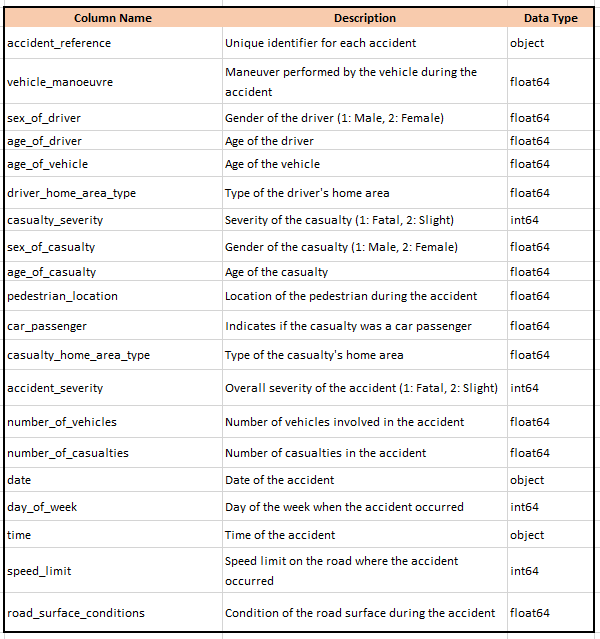

# **4. Machine Learning: Splitting the data into Training and Testing sample**


We dont use the full data for creating the model. Some data is randomly selected and kept aside for checking how good the model is. This is known as Testing Data and the remaining data is called Training data on which the model is built. Typically 80% of data is used as Training data and the rest 20% is used as Tesing data.

In [171]:
# Create a random split
rand_train_set, rand_test_set = train_test_split(combined_data, test_size=0.2, random_state=7)
# Perform stratified splitting
strat_train_set, strat_test_set = train_test_split(combined_data, test_size=0.2, random_state=7,
 stratify=combined_data["accident_severity"])

# Define a function to calculate proportions
def accident_severity_calculated(data):
 return data["accident_severity"].value_counts() / len(data)

# Create a temporary dataframe for easy visualization
sampling_df = pd.DataFrame({
 "Overall": accident_severity_calculated(combined_data),
 "Random test set": accident_severity_calculated(rand_test_set),
 "Stratified test set": accident_severity_calculated(strat_test_set),
}).sort_index()

# Add two columns for the percent of the difference to the overall proportion
sampling_df["Rand. %error"] = 100 * sampling_df["Random test set"] / sampling_df["Overall"] - 100
sampling_df["Strat. %error"] = 100 * sampling_df["Stratified test set"] / sampling_df["Overall"] - 100

# Show the result
sampling_df

,Overall,Random test set,Stratified test set,Rand. %error,Strat. %error
accident_severity,,,,,
1,0.1392,0.1425,0.139,2.370690,-0.143678
2,0.8608,0.8575,0.861,-0.383364,0.023234


The stratified test set generally has a lower percentage error compared to the random test set, indicating that stratified sampling does a better job of matching the overall distribution of accident severity categories.

In [172]:
# Conduct stratified sampling
trainset, testset = train_test_split(combined_data, test_size=0.2,
 stratify=combined_data["accident_severity"], random_state=7)

# Display the distribution of the "accident_severity" categories in the "trainset"
trainset["accident_severity"].value_counts(normalize=True)


accident_severity
2    0.86075
1    0.13925
Name: proportion, dtype: float64

In [173]:
# Display the distribution of the "accident_severity" categories in the "testset"
testset["accident_severity"].value_counts(normalize=True)

accident_severity
2    0.861
1    0.139
Name: proportion, dtype: float64

Both the trainset and testdata shows majority of the cases have fatal accident severity. Indicative that there is imbalance in the dataset makingit plausible to have implication on the predictive model that would be built.

In [174]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(combined_data, test_size=0.2, random_state=7)
print(f"{train_set.shape[0]} train and {test_set.shape[0]} test instances")

8000 train and 2000 test instances


Saving intermediate versions of the data at various stages of processing acts as a backup.

In [175]:
# Save the combined data to a CSV file
combined_data.to_csv('combined_data_variables.csv', index=False)

print("Combined data saved to 'combined_data_variables.csv'")

Combined data saved to 'combined_data_variables.csv'


In [176]:
# Separate the target and predictors
ytrain = train_set["accident_severity"].copy()
Xtrain = train_set.drop("accident_severity", axis=1)
ytest = test_set["accident_severity"].copy()
Xtest = test_set.drop("accident_severity", axis=1)

In [177]:
train_set.head()

,accident_reference,vehicle_manoeuvre,sex_of_driver,age_of_driver,age_of_vehicle,driver_home_area_type,casualty_severity,sex_of_casualty,age_of_casualty,pedestrian_location,car_passenger,casualty_home_area_type,accident_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,speed_limit,road_surface_conditions
4989,10359295,Going ahead other,NaN,NaN,NaN,NaN,Slight,Male,40.0,Not a Pedestrian,Not car passenger,NaN,2,3.0,1.0,2022-02-08 00:00:00,Tuesday,1900-01-01 18:10:00,20,Dry
4498,10358578,Waiting to turn right,Male,51.0,6.0,Urban area,Slight,Female,57.0,Not a Pedestrian,Not car passenger,Urban area,2,2.0,1.0,2022-02-04 00:00:00,Friday,1900-01-01 19:50:00,30,Dry
8876,10364792,Turning right,Male,25.0,9.0,Urban area,Serious,Female,67.0,"In carriageway, crossing elsewhere",Not car passenger,Urban area,1,1.0,1.0,2022-03-11 00:00:00,Friday,1900-01-01 14:23:00,20,Wet or damp
670,10353433,Going ahead other,Male,18.0,8.0,Urban area,Slight,Male,18.0,Not a Pedestrian,Not car passenger,Urban area,2,2.0,1.0,2022-01-07 00:00:00,Friday,1900-01-01 17:40:00,30,Wet or damp
9552,10365772,Going ahead other,Female,28.0,13.0,Urban area,Slight,Female,28.0,Not a Pedestrian,Not car passenger,Urban area,2,1.0,3.0,2022-03-16 00:00:00,Wednesday,1900-01-01 23:20:00,40,Wet or damp


## **5. DESCRIPTIVE STATISTICS AND  DATA EXPLORATION**

This step is performed to guage the overall data. The volume of data, the types of columns present in the data. Initial assessment of the data should be done to identify which columns are Quantitative, Categorical or Qualitative.

There are four commands which are used for Basic data exploration in Python

head() : This helps to see a few sample rows of the data

info() : This provides the summarized information of the data

describe() : This provides the descriptive statistical details of the data

nunique(): This helps us to identify if a column is categorical or continuous

This were used many times in the overall data preprocessing steps.

### **5.1: SUMMARY STATISTICS OF THE DATASET**

Summary statistics provide a high-level overview of the central tendency, dispersion, and shape of the distribution of a dataset's features. These metrics are useful for understanding the data's basic properties and identifying potential anomalies or areas that may require further investigation.

In [178]:
#  Summary Statistics
print("Summary statistics of combined dataset:")
print(combined_data.describe())

Summary statistics of combined dataset:
       age_of_driver  age_of_vehicle  age_of_casualty  number_of_vehicles  \
count     7923.00000     7777.000000      9572.000000         10000.00000   
mean        38.86861        7.713000        36.043356             2.07020   
std         14.19319        5.222338        15.513261             0.74641   
min          6.00000        0.000000         0.000000             1.00000   
25%         28.00000        4.000000        25.000000             2.00000   
50%         36.00000        7.000000        33.000000             2.00000   
75%         48.00000       11.000000        45.000000             2.00000   
max         94.00000       50.000000        92.000000             7.00000   

       number_of_casualties   speed_limit  
count          10000.000000  10000.000000  
mean               1.443400     27.415000  
std                1.040243      8.319537  
min                1.000000     20.000000  
25%                1.000000     20.000000  
50

## **5.2: Visual Exploratory Data Analysis**

# **Univariate analysis**

Provide an understanding of the distribution and characteristics of key variables in your dataset. By examining the histograms and boxplots, we can identify common trends, typical values, and potential outliers, which are crucial for further analysis.

Looking at the distribution of Target variable:

In [179]:
ytrain_series = pd.Series(ytrain)
ytrain_series.value_counts()

print(ytrain_series.value_counts())

accident_severity
2    6893
1    1107
Name: count, dtype: int64


There is imbalance in the target variable which would be further visually explored

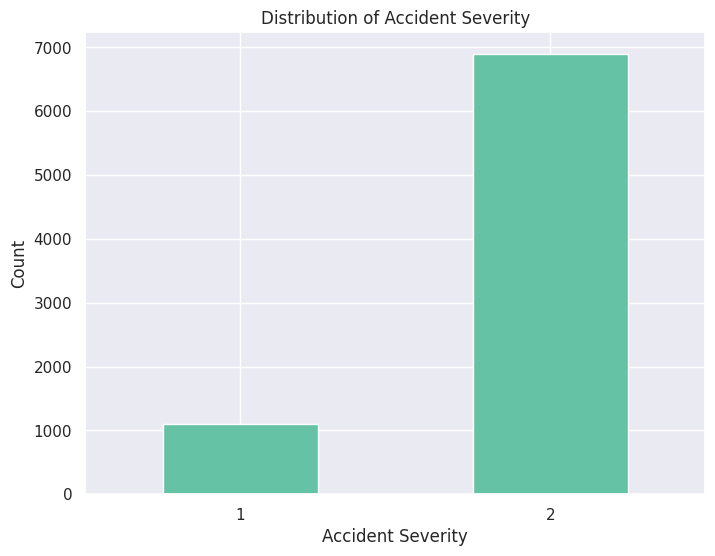

In [180]:
import matplotlib.pyplot as plt
# Size of the plot
plt.figure(figsize=(8, 6))
# Plot the distribution of accident severity
ytrain.value_counts().sort_index().plot(kind="bar")
# Labels and title of the plot
plt.xlabel("Accident Severity")
plt.ylabel("Count")
plt.title("Distribution of Accident Severity")
# Rotate x-axis labels
plt.xticks(rotation=360)
# Show the plot
plt.show()


The bar plot shows that the high number of slight accidents suggests that while accidents are frequent, most of them are not severe. This information is crucial for insurance companies and policy-makers in understanding the general safety on the roads.

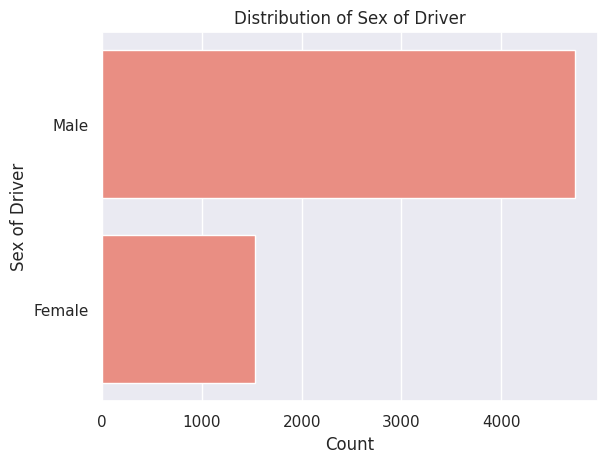

In [181]:
# Distribution of sex_of_casualty
sns.barplot(x=Xtrain['sex_of_driver'].value_counts(), y=Xtrain['sex_of_driver'].value_counts().index,
            color = 'salmon')

# Set title for the plot
plt.title("Distribution of Sex of Driver")
# Add x/y labels
plt.xlabel("Count")
plt.ylabel("Sex of Driver")
# Show the plot
plt.show()


The data plot shows a skewed distribution towards male drivers, indicating that a larger proportion of accidents involve male drivers compared to female drivers.

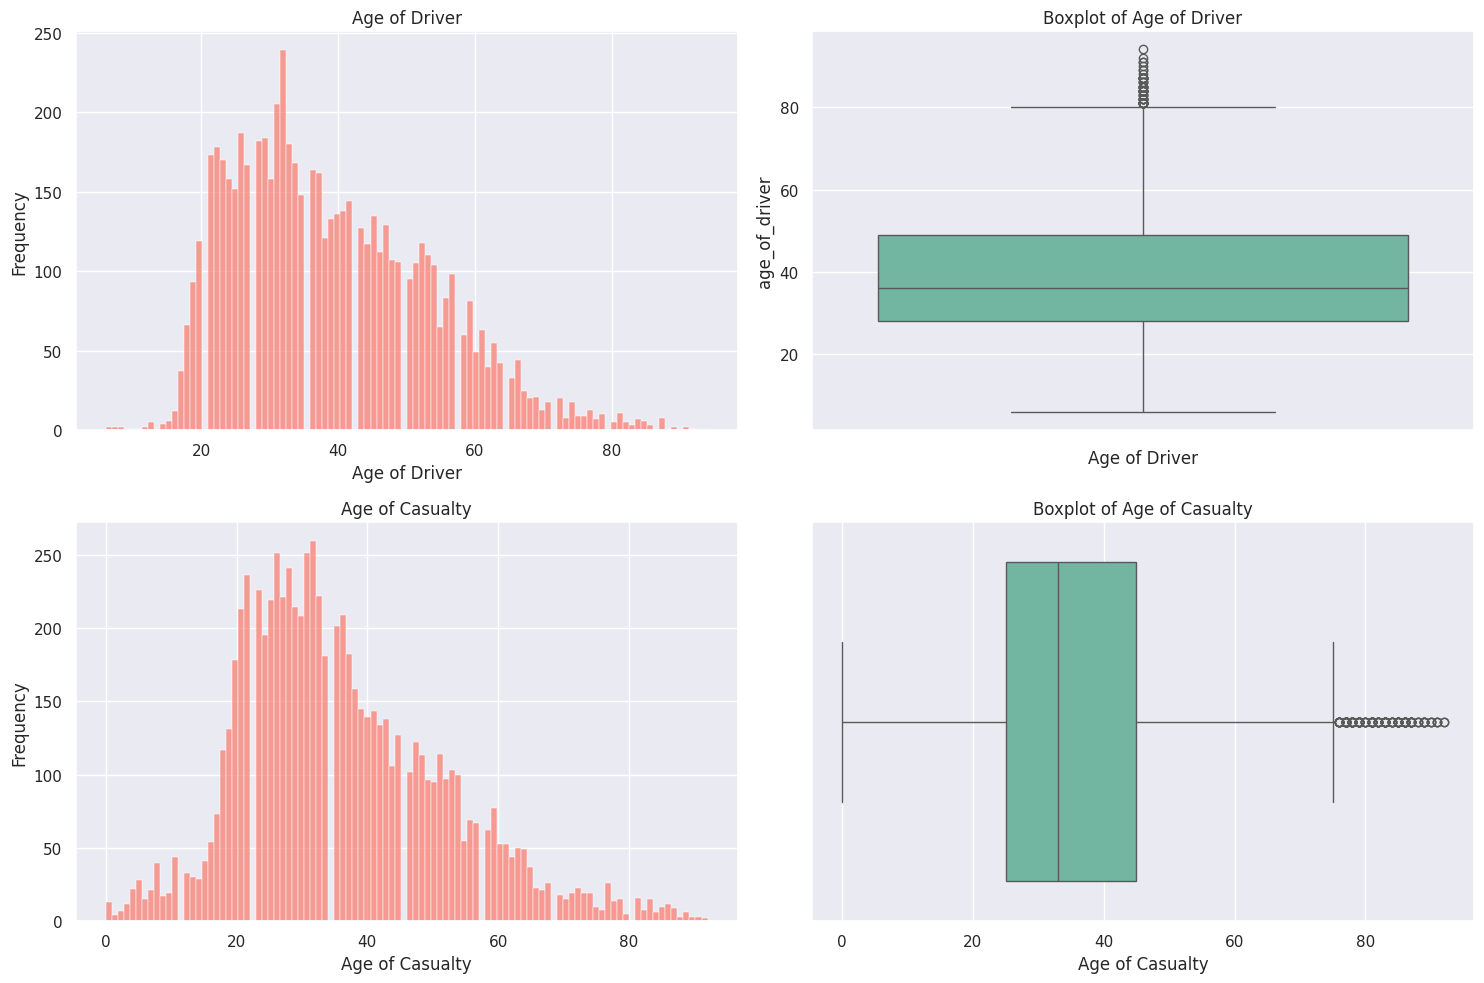

In [182]:
# Create a figure for histograms and boxplots
fig = plt.figure(figsize=(15,10))

# Histogram for age_of_driver
plt.subplot(2,2,1)
hist_driver = sns.histplot(Xtrain['age_of_driver'], bins=100, color = 'salmon')
hist_driver.set_title('Age of Driver')
hist_driver.set(xlabel='Age of Driver', ylabel='Frequency')

# Boxplot for age_of_driver
plt.subplot(2,2,2)
box_driver = sns.boxplot(Xtrain['age_of_driver'])
box_driver.set_title('Boxplot of Age of Driver')
box_driver.set(xlabel='Age of Driver')

# Histogram for age_of_casualty
plt.subplot(2,2,3)
hist_casualty = sns.histplot(Xtrain['age_of_casualty'], bins=100, color = 'salmon')
hist_casualty.set_title('Age of Casualty')
hist_casualty.set(xlabel='Age of Casualty', ylabel='Frequency')

# Boxplot for age_of_casualty
plt.subplot(2,2,4)
box_casualty = sns.boxplot(x=Xtrain['age_of_casualty'])
box_casualty.set_title('Boxplot of Age of Casualty')
box_casualty.set(xlabel='Age of Casualty')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()




Histogram shows the distribution of variable age of drivers, casualties' age which show a concentration between 20 to 40 years.

Boxplot shows that the majority of the data lies between 20 and 40 years.

Age Distribution: Both drivers and casualties are predominantly young adults, suggesting higher risk or exposure for this age group.

Central Tendency: The median ages indicate that accidents are more common among younger populations.

Outliers: The presence of outliers in older age groups for both drivers and casualties shows that while less frequent, older individuals are still involved in accidents.

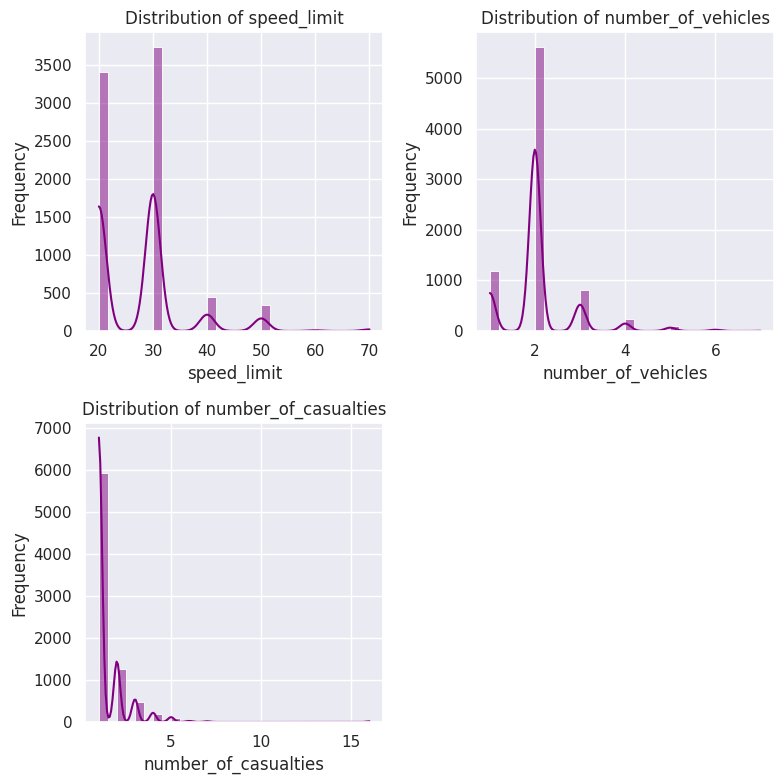

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming Xtrain is your dataframe with the selected variables
# Replace the following sample data with your actual dataframe if not already loaded
# Xtrain = pd.read_csv('your_dataset.csv')

# Create a figure for histograms
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

# List of variables
variables = [ 'speed_limit', 'number_of_vehicles', 'number_of_casualties']

# Plot histograms for each variable
for i, var in enumerate(variables):
    sns.histplot(Xtrain[var], bins=30, kde=True, ax=axs[i//2, i%2], color='purple')
    axs[i//2, i%2].set_title(f'Distribution of {var}')
    axs[i//2, i%2].set_xlabel(var)
    axs[i//2, i%2].set_ylabel('Frequency')

# Remove the empty subplot
fig.delaxes(axs[1, 1])

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


The provided charts display the distributions of  key variables related to traffic accidents: speed limit, number of vehicles, and number of casualties.

Speed Limit (Middle Left):The distribution of speed limits at accident sites shows peaks at 30, 40, and 50 mph.
These speed limits are common in urban and suburban settings, indicating a higher frequency of accidents in these areas.


Number of Vehicles (Middle Right):Most accidents involve one or two vehicles, with a significant peak at two vehicles.
Accidents involving more than three vehicles are relatively rare.


Number of Casualties (Bottom Left):The distribution shows that most accidents result in one or two casualties.
Incidents with higher numbers of casualties are less common.

# **BIVARIATE ANALYSIS**

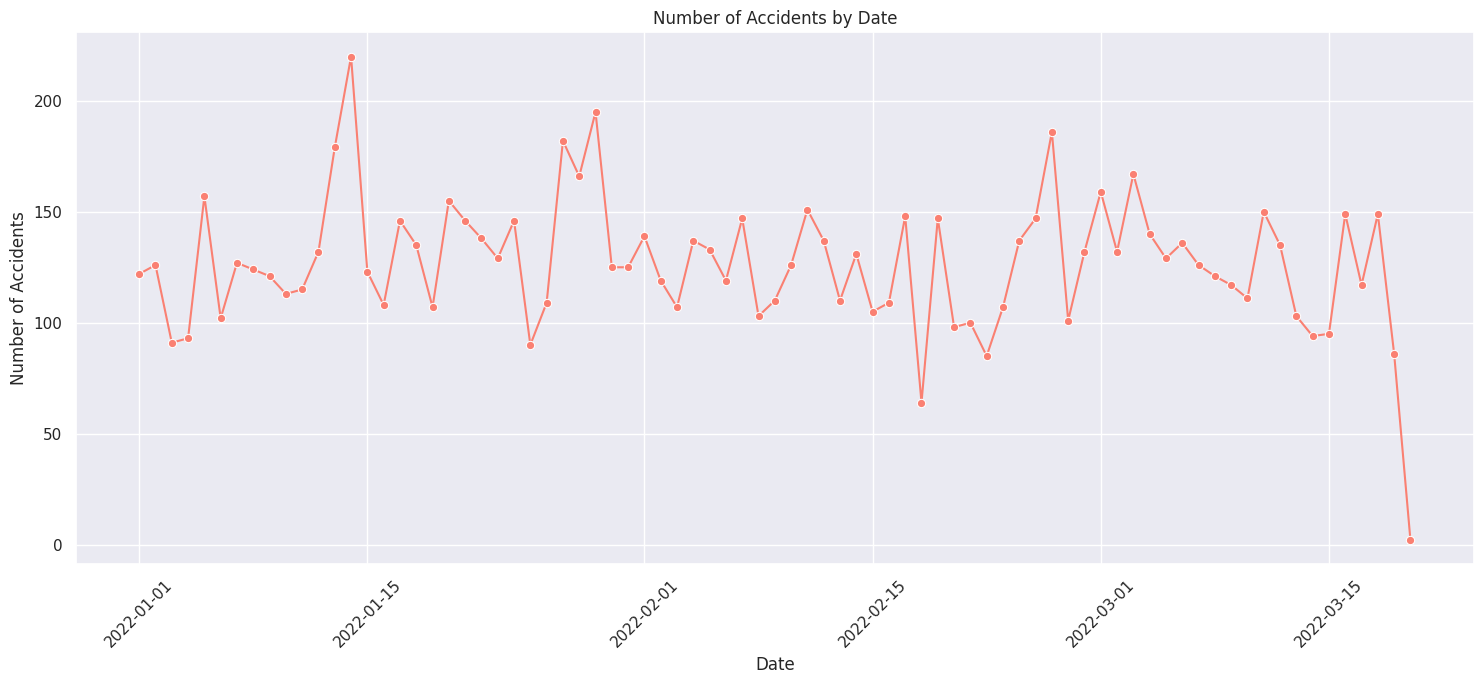

In [184]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the "Date" column to datetime format if not already done
combined_data['date'] = pd.to_datetime(combined_data['date'], format="%d/%m/%Y")

# Group by date and count the number of accidents
accidents_by_date = combined_data['date'].value_counts().sort_index()

# Plot the number of accidents by date
plt.figure(figsize=(15, 7))
sns.lineplot(x=accidents_by_date.index, y=accidents_by_date.values, marker='o', color='salmon')
plt.title('Number of Accidents by Date')
plt.xlabel('Date')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


The line chart illustrates the daily number of accidents over a period from January to March 2022. There is noticeable variability in the data, with peaks indicating higher accident counts occurring sporadically. The overall trend does not show a clear increase or decrease, suggesting fluctuating accident occurrences throughout the observed period.

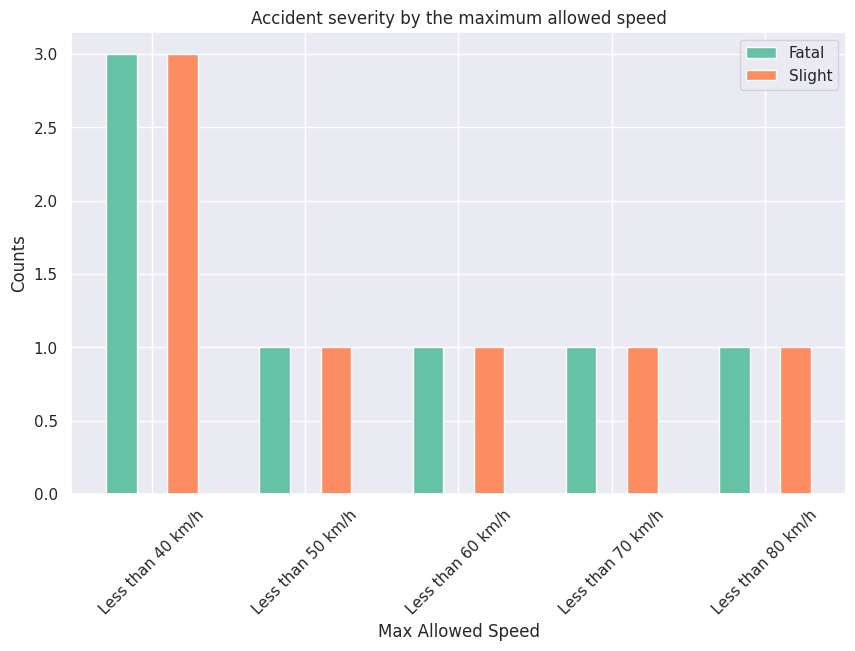

In [185]:
import matplotlib.pyplot as plt
import numpy as np

# Sample DataFrame creation for demonstration purposes
# In actual use case, replace this with your 'train_set' DataFrame
train_set = pd.DataFrame({
    'speed_limit': [10, 20, 30, 40, 50, 60, 70, 10, 20, 30, 40, 50, 60, 70],
    'accident_severity': [1, 2, 1, 2, 1, 2,  1, 2, 1, 2,1,2,1,2]
})

# Correcting speed limit categories for proper mapping
train_set['speed_limit'] = train_set['speed_limit'].astype(str) + ' km/h'
train_set['speed_limit'] = train_set['speed_limit'].replace({
    '10 km/h': 'Less than 40 km/h',
    '20 km/h': 'Less than 40 km/h',
    '30 km/h': 'Less than 40 km/h',
    '40 km/h': 'Less than 50 km/h',
    '50 km/h': 'Less than 60 km/h',
    '60 km/h': 'Less than 70 km/h',
    '70 km/h': 'Less than 80 km/h'
})

# Group by speed limit and severity, then count occurrences
severity_counts = train_set.groupby(['speed_limit', 'accident_severity']).size().unstack(fill_value=0)

# Define the categories and severity levels
categories = ['Less than 40 km/h', 'Less than 50 km/h', 'Less than 60 km/h', 'Less than 70 km/h', 'Less than 80 km/h']
severity_labels = { 1 :'Fatal', 2 :'Slight'}

# Prepare the data for plotting
counts = {label: [] for label in severity_labels.values()}
for category in categories:
    for severity, label in severity_labels.items():
        count = severity_counts.loc[category, severity] if category in severity_counts.index and severity in severity_counts.columns else 0
        counts[label].append(count)

# Create the bar plot
x = np.arange(len(categories))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, counts['Fatal'], width, label='Fatal')

rects2 = ax.bar(x + width, counts['Slight'], width, label='Slight')

# Add labels, title, and legend
ax.set_xlabel('Max Allowed Speed')
ax.set_ylabel('Counts')
ax.set_title('Accident severity by the maximum allowed speed')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45)
ax.legend()

plt.show()

The plot indicates that most accidents occur at speed limits of less than 40 km/h, with a relatively balanced distribution between fatal and slight accidents. As the speed limit increases, the count of accidents decreases, and the distribution between fatal and slight accidents remains relatively consistent.

Indicative that mostly accidents with slight severity is observed.

In [186]:
import plotly.express as px
# Sample DataFrame creation for demonstration purposes
# In actual use case, replace this with your 'train_set' DataFrame
train_set = pd.DataFrame({
    'day_of_week': [1, 2, 3, 4, 5, 6, 7, 1, 2, 3, 4, 5, 6, 7],
    'accident_severity': [1, 2, 1, 2, 1, 2, 1, 2, 1, 2,1 ,2,1,2 ]
})

# Day of the week mapping
day_of_week_mapping = {
    1: 'Sunday',
    2: 'Monday',
    3: 'Tuesday',
    4: 'Wednesday',
    5: 'Thursday',
    6: 'Friday',
    7: 'Saturday'
}

# Map integer values to categorical labels for 'day_of_week' column
train_set['day_of_week'] = train_set['day_of_week'].map(day_of_week_mapping)

# Group by day of the week and severity, then count occurrences
severity_counts = train_set.groupby(['day_of_week', 'accident_severity']).size().unstack(fill_value=0).reset_index()

# Melt the dataframe for better visualization with Plotly
severity_counts_melted = severity_counts.melt(id_vars='day_of_week', value_vars=[1, 2],
                                              var_name='accident_severity', value_name='count')

# Map accident severity to descriptive labels
severity_labels = {1: 'Fatal', 2: 'Slight'}
severity_counts_melted['accident_severity'] = severity_counts_melted['accident_severity'].map(severity_labels)

# Create the bar plot with Plotly
fig = px.bar(severity_counts_melted, x='day_of_week', y='count', color='accident_severity',
             title='Accident Severity by Day of the Week',
             labels={'day_of_week': 'Day of the Week', 'count': 'Number of Accidents', 'accident_severity': 'Accident Severity'},
             category_orders={'day_of_week': list(day_of_week_mapping.values())},
             color_discrete_map={'Fatal': 'pink', 'Slight': 'lightblue'})

# Customize the layout if needed
fig.update_layout(barmode='group', xaxis_tickangle=-45)
fig.show()

Each bar represents the number of accidents for a specific day, with the red portion indicating fatal accidents and the light blue portion indicating slight accidents. The consistent height and color distribution across all days suggest that both fatal and slight accidents occur at a similar rate throughout the week. This implies that the day of the week does not significantly influence the severity of accidents.

In [187]:
# Sample DataFrame creation for demonstration purposes
# In actual use case, replace this with your 'train_set' DataFrame
train_set = pd.DataFrame({
    'accident_severity': [1, 2, 1, 2, 1, 2, 1, 2,1,2,1,2],
    'age_of_driver': [22, 45, 38, 29, 50, 41, 35, 60, 42, 27, 55, 40]
})

# Map accident severity to descriptive labels
severity_mapping = {1: 'Severe', 2: 'Minor'}
train_set['accident_severity'] = train_set['accident_severity'].map(severity_mapping)

# Create the box plot
fig = px.box(train_set, x='accident_severity', y='age_of_driver',
             color='accident_severity',  # Adding color based on accident severity
             title='Age of Driver by Accident Severity',
             labels={'age_of_driver': 'Age of Driver', 'accident_severity': 'Accident Severity'},
             category_orders={"accident_severity": ["Minor",  "Severe"]},  # Adjust categories as needed
             color_discrete_map={"Severe": "red", "Minor": "lightblue"})  # Custom colors

# Customize the layout if needed
fig.update_layout(showlegend=True)
fig.show()


The box plot shows driver ages for minor and severe accidents. Minor accidents have a median age of 35 years, with most drivers aged 30-45. Severe accidents have a higher median age of 45 years, with drivers mostly aged 30-50. Severe accidents involve slightly older drivers compared to minor accidents.

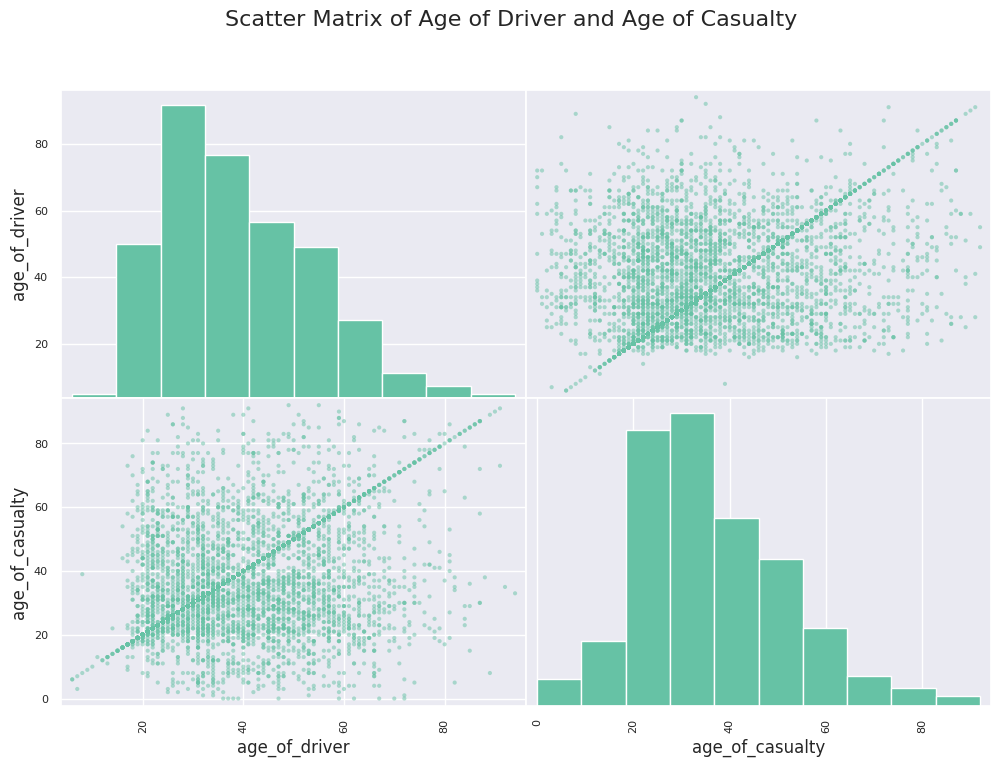

In [188]:
# Scatter matrix
from pandas.plotting import scatter_matrix
# Select only the variables that are most likely to be correlated
vars = ["age_of_driver", "age_of_casualty"]
scatter_matrix(Xtrain[vars], figsize=(12, 8))
# Title for the plot
plt.suptitle('Scatter Matrix of Age of Driver and Age of Casualty', fontsize=16)
# Show the plot
plt.show()


The scatter matrix shows the relationship between the ages of drivers and casualties involved in accidents. The diagonal histograms indicate the age distribution for each variable, with a higher frequency of drivers and casualties aged between 20 to 40 years. The scatter plots demonstrate a positive correlation, suggesting that older drivers are often involved in accidents with older casualties, and younger drivers with younger casualties. This relationship can be useful for understanding demographic trends in accident data.

# **MULTIVARIATE ANALYSIS**

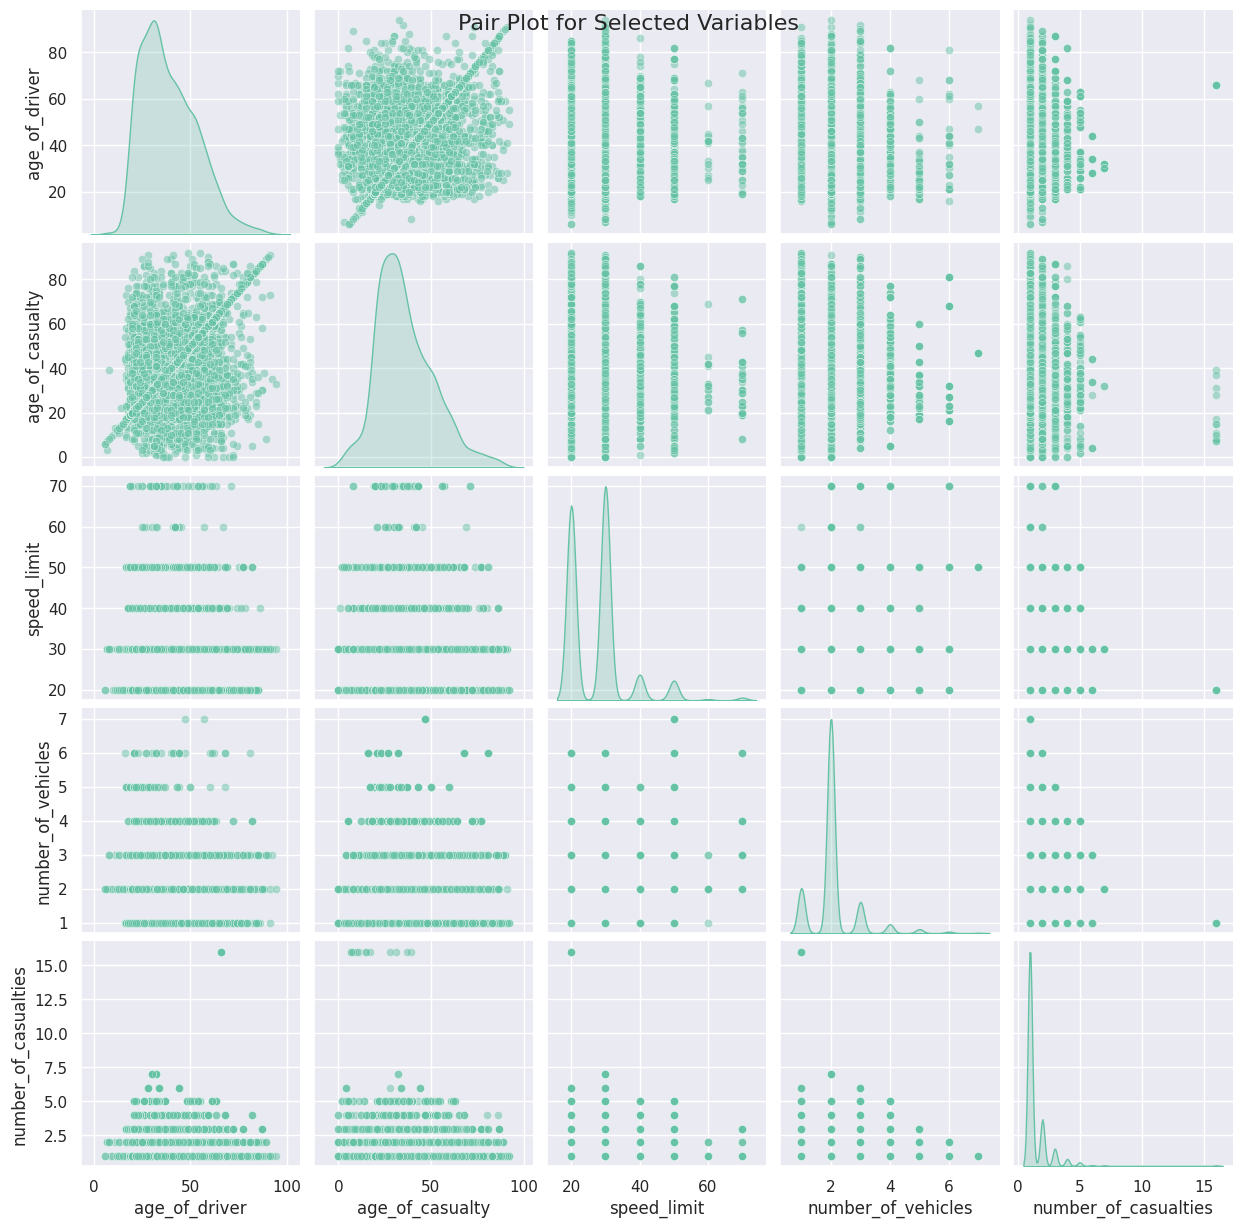

In [189]:
# Pair plot for selected variables
# Define a color palette with light purple
color_palette = sns.color_palette("Purples", 8)

# Pair plot for selected variables with light purple color
selected_vars = ['age_of_driver', 'age_of_casualty', 'speed_limit', 'number_of_vehicles', 'number_of_casualties']
sns.pairplot(Xtrain[selected_vars], diag_kind='kde', plot_kws={'alpha':0.5}, palette=color_palette)
plt.suptitle('Pair Plot for Selected Variables', fontsize=16)
plt.show()

The pair plot provides a comprehensive view of the relationships between key variables related to traffic accidents. Key insights include:

Most accidents involve younger drivers and casualties, typically aged 20-40 years.
Accidents commonly occur at speed limits of 30 and 50 units.
Most accidents involve 1 or 2 vehicles and result in 1 or 2 casualties.
There is a notable correlation between the age of drivers and casualties, suggesting that individuals of similar age groups are often involved in the same accidents.

# **CORRELATION ANALYSIS**

In [190]:
# Calculate the Pearson correlation matrix
corr_matrix = Xtrain.corr(method="pearson", numeric_only=True)
# Apply a color gradient to the correlation matrix and format the precision
corr_matrix.style.background_gradient(cmap='coolwarm', axis=None).format(precision=3)

,age_of_driver,age_of_vehicle,age_of_casualty,number_of_vehicles,number_of_casualties,speed_limit
age_of_driver,1.000,0.107,0.399,-0.038,0.053,0.010
age_of_vehicle,0.107,1.000,0.081,0.024,-0.004,0.022
age_of_casualty,0.399,0.081,1.000,-0.023,-0.063,0.017
number_of_vehicles,-0.038,0.024,-0.023,1.000,0.151,0.216
number_of_casualties,0.053,-0.004,-0.063,0.151,1.000,0.145
speed_limit,0.010,0.022,0.017,0.216,0.145,1.000


The Pearson correlation matrix shows moderate positive correlation between the age of the driver and the age of the casualty (0.399). There is also a positive correlation between the number of vehicles involved and the number of casualties (0.151). Speed limit has low correlations with other variables, indicating minimal direct impact.

# **Statistical Feature Selection using ANOVA test**

In [191]:
import pandas as pd
import numpy as np
from scipy import stats

# Example data
data = {
    'day_of_week': [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7],
    'accident_severity': [1, 2, 2, 3, 1, 2, 2, 3, 1, 2, 2, 3, 1, 2]
}
Xtrain = pd.DataFrame(data)

# Group the data by 'day_of_week' and get 'accident_severity' values for each group
grouped_data = Xtrain.groupby('day_of_week')['accident_severity'].apply(list)

# Perform ANOVA
anova_result = stats.f_oneway(*grouped_data)

# Print the result
print('ANOVA result:', anova_result)

# Check if the result is significant
if anova_result.pvalue < 0.05:
    print('The differences between the group means are statistically significant.')
else:
    print('The differences between the group means are not statistically significant.')


ANOVA result: F_onewayResult(statistic=1.142857142857143, pvalue=0.4269740049865851)
The differences between the group means are not statistically significant.


In [192]:
import pandas as pd
import numpy as np
from scipy import stats

# Example data
data = {
    'vehicle_manoeuvre_group': ['Turning right', 'Turning right', 'Turning left', 'Turning left', 'Moving off', 'Moving off'],
    'accident_severity': [1, 2, 2, 3, 1, 2]
}
Xtrain = pd.DataFrame(data)

# Prepare the data for ANOVA
grouped_data = Xtrain.groupby('vehicle_manoeuvre_group')['accident_severity'].apply(list)

# Perform ANOVA
anova_result = stats.f_oneway(*grouped_data)

# Print the result
print('ANOVA result:', anova_result)

# Check if the result is significant
if anova_result.pvalue < 0.05:
    print('The differences between the group means are statistically significant.')
else:
    print('The differences between the group means are not statistically significant.')


ANOVA result: F_onewayResult(statistic=1.3333333333333335, pvalue=0.3852036397635877)
The differences between the group means are not statistically significant.


Vehicle_manoeuvre group is NOT correlated with Accident severity | P-Value: 0.3852036397635877

Day of week is NOT correlated with Accident_severity | P-Value: 0.4269740049865851

# **6. DATA PREPROCESSING**

### **6.1: FEATURE ENGINEERING**

Categorizing Time of Day:

In [193]:
import pandas as pd

# Function to categorize time of day
def categorize_time_of_day(time):
    if isinstance(time, str):
        hour = int(time.split(':')[0])
    else:  # Assuming time is a Timestamp object
        hour = time.hour

    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'

# Apply the function to create a new feature in the trainset DataFrame
trainset['time_of_day'] = trainset['time'].apply(categorize_time_of_day)

# Apply the same function to the testset DataFrame
testset['time_of_day'] = testset['time'].apply(categorize_time_of_day)

# Drop the original 'time' column from both DataFrames
trainset.drop(columns=['time'], inplace=True)
testset.drop(columns=['time'], inplace=True)

# Display the updated DataFrames
print("Training Set after creating time_of_day:")
print(trainset[['time_of_day']].head())
print("\nTest Set after creating time_of_day:")
print(testset[['time_of_day']].head())

Training Set after creating time_of_day:
     time_of_day
8570       Night
3943     Evening
9779   Afternoon
1766     Evening
5085   Afternoon

Test Set after creating time_of_day:
     time_of_day
3902     Morning
6152     Morning
7798   Afternoon
2591     Evening
3913     Morning


This feature engineering step categorizes the 'time' column into four time-of-day categories: Morning, Afternoon, Evening, and Night, based on the hour. This categorization is achieved by defining and applying the categorize_time_of_day function to both the training and testing datasets. The function checks the hour and assigns the appropriate time-of-day label.

In [194]:
# Function to create the Vehicle Manoeuvre Group feature - reclassification
def create_vehicle_manoeuvre_group(data):
    # Define broader categories for vehicle manoeuvres
    vehicle_manoeuvres = {
        'Going ahead other': ['Going ahead other'],
        'Turning right': ['Turning right'],
        'Moving off': ['Moving off'],
        'Waiting': ['Waiting to go - held up', 'Waiting to turn right', 'Waiting to turn left'],
        'Slowing or stopping': ['Slowing or stopping'],
        'Turning left': ['Turning left'],
        'Going ahead right-hand bend': ['Going ahead right-hand bend'],
        'Going ahead left-hand bend': ['Going ahead left-hand bend'],
        'Overtaking': [
            'Overtaking moving vehicle - offside', 'Overtaking static vehicle - offside',
            'Overtaking - nearside'
        ],
        'Parked': ['Parked'],
        'U-turn': ['U-turn'],
        'Changing lane': ['Changing lane to left', 'Changing lane to right'],
        'Reversing': ['Reversing']
    }

    # Initialize the new feature column
    data['vehicle_manoeuvre_group'] = 'Other'

    # Iterate over the vehicle manoeuvres and assign broader categories to each row
    for group, manoeuvres in vehicle_manoeuvres.items():
        data.loc[data['vehicle_manoeuvre'].isin(manoeuvres), 'vehicle_manoeuvre_group'] = group

    return data

# Sample DataFrame creation for demonstration purposes
# (Assuming trainset and testset are your existing DataFrames)
# Apply the function to create the vehicle manoeuvre group feature
trainset = create_vehicle_manoeuvre_group(trainset)
testset = create_vehicle_manoeuvre_group(testset)

# Delete original 'vehicle_manoeuvre' column on training and testing data
trainset.drop(columns=['vehicle_manoeuvre'], inplace=True)
testset.drop(columns=['vehicle_manoeuvre'], inplace=True)

# Display the updated DataFrame
print("Training Set after creating vehicle_manoeuvre_group:")
print(trainset[['vehicle_manoeuvre_group']].head())
print("\nTest Set after creating vehicle_manoeuvre_group:")
print(testset[['vehicle_manoeuvre_group']].head())

Training Set after creating vehicle_manoeuvre_group:
     vehicle_manoeuvre_group
8570                  Parked
3943                   Other
9779                   Other
1766                   Other
5085                   Other

Test Set after creating vehicle_manoeuvre_group:
     vehicle_manoeuvre_group
3902                   Other
6152                   Other
7798           Turning right
2591           Changing lane
3913                   Other


This reclassifies the 'vehicle_manoeuvre' column into broader categories to create a new feature, 'vehicle_manoeuvre_group'. The process involves defining broader categories, initializing the new feature, reclassifying the original manoeuvre values, and applying the function to both training and testing datasets.

In [195]:
# Drop the 'accident_reference' column from the training set
trainset = trainset.drop(columns=['accident_reference'])

# Drop the 'accident_reference' column from the testing set
testset = testset.drop(columns=['accident_reference'])

The 'accident_reference' column is being dropped from both the training and testing datasets because it serves as a unique identifier for each accident record and does not provide any predictive value for the model. This column was essential for merging the three datasets (casualty, collision, and vehicle) to ensure that the records from different datasets were accurately combined.

## **6.2: HANDLING MISSING VALUES**

---



Simple Imputer

In [196]:
# check number of missing values in testing data
testset.isnull().sum()


sex_of_driver              439
age_of_driver              450
age_of_vehicle             463
driver_home_area_type      455
casualty_severity            0
sex_of_casualty             37
age_of_casualty             95
pedestrian_location          0
car_passenger               10
casualty_home_area_type    133
accident_severity            0
number_of_vehicles           0
number_of_casualties         0
date                         0
day_of_week                  0
speed_limit                  0
road_surface_conditions     87
time_of_day                  0
vehicle_manoeuvre_group      0
dtype: int64

In [197]:
# check number of missing values in training data
trainset.isnull().sum()

sex_of_driver              1700
age_of_driver              1627
age_of_vehicle             1760
driver_home_area_type      1777
casualty_severity             0
sex_of_casualty             140
age_of_casualty             333
pedestrian_location           0
car_passenger                23
casualty_home_area_type     555
accident_severity             0
number_of_vehicles            0
number_of_casualties          0
date                          0
day_of_week                   0
speed_limit                   0
road_surface_conditions     290
time_of_day                   0
vehicle_manoeuvre_group       0
dtype: int64

In [198]:
trainset.shape

(8000, 19)

In [199]:
testset.shape

(2000, 19)

The missing values are handled separately for both categorical and numeric variables.


In [200]:
from sklearn.impute import SimpleImputer
import pandas as pd

# Define the numeric columns
numeric_columns = [
     'age_of_driver',
    'age_of_vehicle', 'age_of_casualty', 'number_of_vehicles',
    'number_of_casualties', 'speed_limit'
]

# Define the categorical columns
categorical_columns = [
    'sex_of_driver', 'driver_home_area_type',
    'casualty_severity', 'sex_of_casualty', 'pedestrian_location',
     'car_passenger',
     'casualty_home_area_type', 'accident_severity',
    'date', 'day_of_week',
    'road_surface_conditions',
    'time_of_day', 'vehicle_manoeuvre_group'
]

# Select numerical columns from training set
numerical_columns_train = trainset[numeric_columns]

# Select categorical columns from training set
categorical_columns_train = trainset[categorical_columns]

# Mean/Median Imputation
imputer_num_median = SimpleImputer(strategy="median")
train_num_median = pd.DataFrame(imputer_num_median.fit_transform(numerical_columns_train),
                                columns=numerical_columns_train.columns,
                                index=numerical_columns_train.index)

# Most Frequent Imputation for Categorical Columns
imputer_cat_frequent = SimpleImputer(strategy="most_frequent")
train_cat_frequent = pd.DataFrame(imputer_cat_frequent.fit_transform(categorical_columns_train),
                                  columns=categorical_columns_train.columns,
                                  index=categorical_columns_train.index)

print(train_num_median.isnull().sum())

age_of_driver           0
age_of_vehicle          0
age_of_casualty         0
number_of_vehicles      0
number_of_casualties    0
speed_limit             0
dtype: int64


KNN IMPUTER:

In [201]:
from sklearn.impute import KNNImputer

# K-Nearest Neighbors (KNN) Imputation
imputer_knn = KNNImputer(n_neighbors=5)
train_num_knn = pd.DataFrame(imputer_knn.fit_transform(numerical_columns_train),
                             columns=numerical_columns_train.columns,
                             index=numerical_columns_train.index)
print(train_num_knn.isnull().sum())

age_of_driver           0
age_of_vehicle          0
age_of_casualty         0
number_of_vehicles      0
number_of_casualties    0
speed_limit             0
dtype: int64


In [202]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Iterative Imputation
imputer_iter = IterativeImputer(max_iter=10, random_state=0)
train_num_iter = pd.DataFrame(imputer_iter.fit_transform(numerical_columns_train),
                              columns=numerical_columns_train.columns,
                              index=numerical_columns_train.index)
print(train_num_iter.isnull().sum())

age_of_driver           0
age_of_vehicle          0
age_of_casualty         0
number_of_vehicles      0
number_of_casualties    0
speed_limit             0
dtype: int64


## **6.3 DUMMY VARIABLES**

The categorical variables are converted to dummy variables using OneHotEncoder from 'scikit-learn' library

In [203]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(drop="first",  handle_unknown='ignore', sparse=False)

In [204]:
# Categorical columns to transform except target variable
cat_cols= [
    'sex_of_driver','driver_home_area_type',
    'casualty_severity', 'sex_of_casualty', 'pedestrian_location',
    'car_passenger',
    'casualty_home_area_type',
    'date', 'day_of_week',
    'road_surface_conditions',
    'time_of_day', 'vehicle_manoeuvre_group']


In [205]:
# fit an encoder and transform the **trainset**
cat_vals = trainset[cat_cols].to_numpy()
cat_vals

array([[nan, nan, 'Slight', ..., 'Dry', 'Night', 'Parked'],
       ['Male', 'Urban area', 'Slight', ..., 'Dry', 'Evening', 'Other'],
       ['Female', 'Urban area', 'Slight', ..., 'Dry', 'Afternoon',
        'Other'],
       ...,
       ['Male', 'Urban area', 'Serious', ..., 'Wet or damp', 'Night',
        'Other'],
       [nan, 'Urban area', 'Slight', ..., 'Wet or damp', 'Evening',
        'Other'],
       ['Female', 'Urban area', 'Slight', ..., 'Wet or damp',
        'Afternoon', 'Moving off']], dtype=object)

In [206]:
# Fit and transform the categorical columns
transformed = one_hot_encoder.fit_transform(cat_vals)
transformed

array([[0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [207]:
# the names of the new columns
new_col_names = one_hot_encoder.get_feature_names_out(cat_cols)
new_col_names

array(['sex_of_driver_Male', 'sex_of_driver_nan',
       'driver_home_area_type_Small town',
       'driver_home_area_type_Urban area', 'driver_home_area_type_nan',
       'casualty_severity_Serious', 'casualty_severity_Slight',
       'sex_of_casualty_Male', 'sex_of_casualty_nan',
       'pedestrian_location_Crossing in zig-zag approach lines',
       'pedestrian_location_Crossing in zig-zag exit lines',
       'pedestrian_location_Crossing on pedestrian crossing facility',
       'pedestrian_location_In carriageway, crossing elsewhere',
       'pedestrian_location_In carriageway, not crossing',
       'pedestrian_location_In centre of carriageway - not on refuge, island or central reservation',
       'pedestrian_location_Not a Pedestrian',
       'pedestrian_location_On footway or verge',
       'pedestrian_location_On refuge, central island or central reservation',
       'pedestrian_location_Unknown or other',
       'car_passenger_Not car passenger',
       'car_passenger_Rear se

In [208]:
trainset = trainset.copy()

In [209]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [210]:
# put the transformed data as columns in the trainset dataframe
for i, new_col_name in enumerate(new_col_names):
    trainset[new_col_name] = transformed[:,i]

# check if the dummies are produced correctly in the trainset
trainset.head()

,sex_of_driver,age_of_driver,age_of_vehicle,driver_home_area_type,casualty_severity,sex_of_casualty,age_of_casualty,pedestrian_location,car_passenger,casualty_home_area_type,...,vehicle_manoeuvre_group_Moving off,vehicle_manoeuvre_group_Other,vehicle_manoeuvre_group_Overtaking,vehicle_manoeuvre_group_Parked,vehicle_manoeuvre_group_Reversing,vehicle_manoeuvre_group_Slowing or stopping,vehicle_manoeuvre_group_Turning left,vehicle_manoeuvre_group_Turning right,vehicle_manoeuvre_group_U-turn,vehicle_manoeuvre_group_Waiting
8570,NaN,NaN,7.0,NaN,Slight,Female,32.0,Not a Pedestrian,Not car passenger,Urban area,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3943,Male,28.0,1.0,Urban area,Slight,Male,28.0,Not a Pedestrian,Not car passenger,Urban area,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9779,Female,43.0,8.0,Urban area,Slight,Female,43.0,Not a Pedestrian,Not car passenger,Urban area,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1766,Male,61.0,4.0,Urban area,Slight,Female,35.0,Not a Pedestrian,Rear seat passenger,Urban area,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5085,Male,52.0,NaN,Urban area,Slight,Male,16.0,"In centre of carriageway - not on refuge, isla...",Not car passenger,Urban area,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [211]:
# delete the original categorical columns
trainset = trainset.drop(cat_cols, axis=1)

In [212]:
trainset.head()

,age_of_driver,age_of_vehicle,age_of_casualty,accident_severity,number_of_vehicles,number_of_casualties,speed_limit,sex_of_driver_Male,sex_of_driver_nan,driver_home_area_type_Small town,...,vehicle_manoeuvre_group_Moving off,vehicle_manoeuvre_group_Other,vehicle_manoeuvre_group_Overtaking,vehicle_manoeuvre_group_Parked,vehicle_manoeuvre_group_Reversing,vehicle_manoeuvre_group_Slowing or stopping,vehicle_manoeuvre_group_Turning left,vehicle_manoeuvre_group_Turning right,vehicle_manoeuvre_group_U-turn,vehicle_manoeuvre_group_Waiting
8570,NaN,7.0,32.0,2,4.0,1.0,30,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3943,28.0,1.0,28.0,2,2.0,1.0,20,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9779,43.0,8.0,43.0,2,2.0,1.0,30,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1766,61.0,4.0,35.0,2,2.0,5.0,20,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5085,52.0,NaN,16.0,2,1.0,3.0,30,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [213]:
testset.head()

,sex_of_driver,age_of_driver,age_of_vehicle,driver_home_area_type,casualty_severity,sex_of_casualty,age_of_casualty,pedestrian_location,car_passenger,casualty_home_area_type,accident_severity,number_of_vehicles,number_of_casualties,date,day_of_week,speed_limit,road_surface_conditions,time_of_day,vehicle_manoeuvre_group
3902,Female,45.0,NaN,Urban area,Serious,Female,45.0,Not a Pedestrian,Not car passenger,Urban area,1,2.0,1.0,2022-01-31 00:00:00,Monday,30,Dry,Morning,Other
6152,Female,NaN,NaN,Urban area,Slight,Female,NaN,Not a Pedestrian,Not car passenger,Urban area,2,2.0,1.0,2022-02-17 00:00:00,Thursday,30,Dry,Morning,Other
7798,Male,25.0,8.0,Urban area,Slight,Male,17.0,Not a Pedestrian,Not car passenger,Urban area,2,2.0,1.0,2022-03-03 00:00:00,Thursday,30,Dry,Afternoon,Turning right
2591,Male,45.0,10.0,Urban area,Serious,Male,42.0,Not a Pedestrian,Not car passenger,Urban area,1,2.0,1.0,2022-01-21 00:00:00,Friday,30,Dry,Evening,Changing lane
3913,Male,32.0,4.0,Urban area,Slight,Male,32.0,Not a Pedestrian,Not car passenger,Urban area,2,2.0,1.0,2022-01-13 00:00:00,Thursday,30,Dry,Morning,Other


In [214]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [215]:
testset = testset.copy()

In [216]:
# transform the **testset** using the encoder fitted on trainset
cat_vals = testset[cat_cols]
transformed = one_hot_encoder.transform(cat_vals)

# put the transformed data as columns in the testset dataframe
for i, new_col_name in enumerate(new_col_names):
    testset[new_col_name] = transformed[:,i]

# check if the dummies are produced correctly in the testset
testset.head()

,sex_of_driver,age_of_driver,age_of_vehicle,driver_home_area_type,casualty_severity,sex_of_casualty,age_of_casualty,pedestrian_location,car_passenger,casualty_home_area_type,...,vehicle_manoeuvre_group_Moving off,vehicle_manoeuvre_group_Other,vehicle_manoeuvre_group_Overtaking,vehicle_manoeuvre_group_Parked,vehicle_manoeuvre_group_Reversing,vehicle_manoeuvre_group_Slowing or stopping,vehicle_manoeuvre_group_Turning left,vehicle_manoeuvre_group_Turning right,vehicle_manoeuvre_group_U-turn,vehicle_manoeuvre_group_Waiting
3902,Female,45.0,NaN,Urban area,Serious,Female,45.0,Not a Pedestrian,Not car passenger,Urban area,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6152,Female,NaN,NaN,Urban area,Slight,Female,NaN,Not a Pedestrian,Not car passenger,Urban area,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7798,Male,25.0,8.0,Urban area,Slight,Male,17.0,Not a Pedestrian,Not car passenger,Urban area,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2591,Male,45.0,10.0,Urban area,Serious,Male,42.0,Not a Pedestrian,Not car passenger,Urban area,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3913,Male,32.0,4.0,Urban area,Slight,Male,32.0,Not a Pedestrian,Not car passenger,Urban area,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [217]:
# delete the original categorical columns
testset = testset.drop(cat_cols, axis=1)

In [218]:
testset.head()

,age_of_driver,age_of_vehicle,age_of_casualty,accident_severity,number_of_vehicles,number_of_casualties,speed_limit,sex_of_driver_Male,sex_of_driver_nan,driver_home_area_type_Small town,...,vehicle_manoeuvre_group_Moving off,vehicle_manoeuvre_group_Other,vehicle_manoeuvre_group_Overtaking,vehicle_manoeuvre_group_Parked,vehicle_manoeuvre_group_Reversing,vehicle_manoeuvre_group_Slowing or stopping,vehicle_manoeuvre_group_Turning left,vehicle_manoeuvre_group_Turning right,vehicle_manoeuvre_group_U-turn,vehicle_manoeuvre_group_Waiting
3902,45.0,NaN,45.0,1,2.0,1.0,30,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6152,NaN,NaN,NaN,2,2.0,1.0,30,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7798,25.0,8.0,17.0,2,2.0,1.0,30,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2591,45.0,10.0,42.0,1,2.0,1.0,30,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3913,32.0,4.0,32.0,2,2.0,1.0,30,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [219]:
# Separate the target and predictors again
ytrain = trainset["accident_severity"].copy()
Xtrain = trainset.drop("accident_severity", axis=1)
ytest = testset["accident_severity"].copy()
Xtest = testset.drop("accident_severity", axis=1)


## **6.4: OTHER IMPUTATION TECHNIQUE FOR HANDLING MISSING VALUES**

KNN IMPUTER

In [220]:
# Create a copy of the original training DataFrames
trainset_tmp = trainset.copy()
# Exclude the target variable from trainset_tmp
predictors_train = trainset_tmp.drop(columns=['accident_severity'])
# Mask approximately 10% of the values with NaN
predictors_train = predictors_train.mask(np.random.random(predictors_train.shape) < 0.1, other=np.NaN)
# Check the sum of missing values
print(predictors_train.isnull().sum())

age_of_driver                                  2274
age_of_vehicle                                 2390
age_of_casualty                                1074
number_of_vehicles                              799
number_of_casualties                            821
                                               ... 
vehicle_manoeuvre_group_Slowing or stopping     831
vehicle_manoeuvre_group_Turning left            806
vehicle_manoeuvre_group_Turning right           770
vehicle_manoeuvre_group_U-turn                  759
vehicle_manoeuvre_group_Waiting                 789
Length: 135, dtype: int64


In [221]:
# Create a copy of the original testing DataFrames
testset_tmp = testset.copy()
# Exclude the target variable from testset_tmp
predictors_test = testset_tmp.drop(columns=['accident_severity'])
# Mask approximately 10% of the values with NaN
predictors_test= predictors_test.mask(np.random.random(predictors_test.shape) < .1, other=np.NaN)
# Check the sum of missing values
predictors_test.isnull().sum()

age_of_driver                                  588
age_of_vehicle                                 619
age_of_casualty                                304
number_of_vehicles                             208
number_of_casualties                           203
                                              ... 
vehicle_manoeuvre_group_Slowing or stopping    210
vehicle_manoeuvre_group_Turning left           217
vehicle_manoeuvre_group_Turning right          193
vehicle_manoeuvre_group_U-turn                 190
vehicle_manoeuvre_group_Waiting                204
Length: 135, dtype: int64

In [222]:
# Fit the imputer to the predictors from the TRAINING set (if not already done)
# Import necessary library
from sklearn.impute import SimpleImputer
# Initialize the imputer
imputer = SimpleImputer(strategy='mean') # Or any other desired strategy
imputer.fit(predictors_train)  # Assuming 'predictors_train' is available from the training phase

"""Fit the imputer to the predictors_test and execute imputation by transforming
the predictors_test. Then, convert the output back to a DataFrame."""
predictors_test = pd.DataFrame(imputer.transform(predictors_test),
 columns=predictors_test.columns,
 index=predictors_test.index)

# check if there are missing values now
predictors_test.isnull().sum()

age_of_driver                                  0
age_of_vehicle                                 0
age_of_casualty                                0
number_of_vehicles                             0
number_of_casualties                           0
                                              ..
vehicle_manoeuvre_group_Slowing or stopping    0
vehicle_manoeuvre_group_Turning left           0
vehicle_manoeuvre_group_Turning right          0
vehicle_manoeuvre_group_U-turn                 0
vehicle_manoeuvre_group_Waiting                0
Length: 135, dtype: int64

# **ITERATIVE IMPUTER**

In [223]:
# Create a copy of the original training DataFrames
trainset_tmp = trainset.copy()
# Exclude the target variable from trainset_tmp
predictors_train = trainset_tmp.drop(columns=['accident_severity'])
# Mask approximately 10% of the values with NaN
predictors_train = predictors_train.mask(np.random.random(predictors_train.shape) < 0.1, other=np.NaN)
# Check the sum of missing values
print(predictors_train.isnull().sum())


age_of_driver                                  2297
age_of_vehicle                                 2428
age_of_casualty                                1135
number_of_vehicles                              805
number_of_casualties                            781
                                               ... 
vehicle_manoeuvre_group_Slowing or stopping     764
vehicle_manoeuvre_group_Turning left            757
vehicle_manoeuvre_group_Turning right           803
vehicle_manoeuvre_group_U-turn                  799
vehicle_manoeuvre_group_Waiting                 782
Length: 135, dtype: int64


In [224]:
# Create a copy of the original testing DataFrames
testset_tmp = testset.copy()
# Exclude the target variable from testset_tmp
predictors_test = testset_tmp.drop(columns=['accident_severity'])
# Mask approximately 10% of the values with NaN
predictors_test= predictors_test.mask(np.random.random(predictors_test.shape) < .1, other=np.NaN)
# Check the sum of missing values
predictors_test.isnull().sum()


age_of_driver                                  597
age_of_vehicle                                 632
age_of_casualty                                272
number_of_vehicles                             195
number_of_casualties                           208
                                              ... 
vehicle_manoeuvre_group_Slowing or stopping    196
vehicle_manoeuvre_group_Turning left           185
vehicle_manoeuvre_group_Turning right          202
vehicle_manoeuvre_group_U-turn                 201
vehicle_manoeuvre_group_Waiting                215
Length: 135, dtype: int64

In [225]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd

# Instantiate an iterative imputer with a maximum of 20 iterations (corrected from max_iter=1)
imputer = IterativeImputer(max_iter=20)  # Adjust 'max_iter' as needed based on convergence diagnostics

# Impute missing values in the training predictors dataframe using the imputer and update the dataframe
predictors_train = pd.DataFrame(imputer.fit_transform(predictors_train),
                                columns=predictors_train.columns,
                                index=predictors_train.index)

# Check for any remaining missing values in the training predictors dataframe
missing_values_after_imputation = predictors_train.isnull().sum()

# Print the number of missing values per column
print(missing_values_after_imputation)

# Optionally, you can check for any columns that still have missing values and consider additional handling
if missing_values_after_imputation.any():
    print("Warning: There are still missing values in the data.")
else:
    print("No missing values remain in the training data.")

age_of_driver                                  0
age_of_vehicle                                 0
age_of_casualty                                0
number_of_vehicles                             0
number_of_casualties                           0
                                              ..
vehicle_manoeuvre_group_Slowing or stopping    0
vehicle_manoeuvre_group_Turning left           0
vehicle_manoeuvre_group_Turning right          0
vehicle_manoeuvre_group_U-turn                 0
vehicle_manoeuvre_group_Waiting                0
Length: 135, dtype: int64
No missing values remain in the training data.


The missing values in the training data is handled here using the imputation technique

In [226]:
print(predictors_train.dtypes)

age_of_driver                                  float64
age_of_vehicle                                 float64
age_of_casualty                                float64
number_of_vehicles                             float64
number_of_casualties                           float64
                                                ...   
vehicle_manoeuvre_group_Slowing or stopping    float64
vehicle_manoeuvre_group_Turning left           float64
vehicle_manoeuvre_group_Turning right          float64
vehicle_manoeuvre_group_U-turn                 float64
vehicle_manoeuvre_group_Waiting                float64
Length: 135, dtype: object


In [227]:
predictors_train['age_of_driver'] = predictors_train['age_of_driver'].fillna(predictors_train['age_of_driver'].mean())

In [228]:
predictors_test['age_of_driver'] = predictors_test['age_of_driver'].fillna(predictors_train['age_of_driver'].mean())

In [229]:
# Impute missing values in the testing predictors dataframe using the imputer and update the dataframe
predictors_test = pd.DataFrame(imputer.transform(predictors_test),
 columns=predictors_test.columns,
 index=predictors_test.index)
# Check for any remaining missing values in the testing predictors dataframe
predictors_test.isnull().sum()


age_of_driver                                  0
age_of_vehicle                                 0
age_of_casualty                                0
number_of_vehicles                             0
number_of_casualties                           0
                                              ..
vehicle_manoeuvre_group_Slowing or stopping    0
vehicle_manoeuvre_group_Turning left           0
vehicle_manoeuvre_group_Turning right          0
vehicle_manoeuvre_group_U-turn                 0
vehicle_manoeuvre_group_Waiting                0
Length: 135, dtype: int64

The missing values here are handled well.

additioanl preprocessing steps

In [230]:
# Combine predictors and target variable on training data
trainset = predictors_train.merge(trainset['accident_severity'], left_index=True, right_index=True)

In [231]:
# Combine predictors and target variable on testing data
testset = predictors_test.merge(testset['accident_severity'], left_index=True, right_index=True)

In [232]:
# Separate the target and predictors again
ytrain = trainset["accident_severity"].copy()
Xtrain = trainset.drop("accident_severity", axis=1)
ytest = testset["accident_severity"].copy()
Xtest = testset.drop("accident_severity", axis=1)


In [233]:
# Display updated trainset
trainset.head(100)

,age_of_driver,age_of_vehicle,age_of_casualty,number_of_vehicles,number_of_casualties,speed_limit,sex_of_driver_Male,sex_of_driver_nan,driver_home_area_type_Small town,driver_home_area_type_Urban area,...,vehicle_manoeuvre_group_Other,vehicle_manoeuvre_group_Overtaking,vehicle_manoeuvre_group_Parked,vehicle_manoeuvre_group_Reversing,vehicle_manoeuvre_group_Slowing or stopping,vehicle_manoeuvre_group_Turning left,vehicle_manoeuvre_group_Turning right,vehicle_manoeuvre_group_U-turn,vehicle_manoeuvre_group_Waiting,accident_severity
8570,34.285307,7.000000,32.000000,4.000000,1.541969,30.0,0.000000,1.0,0.000000,0.004097,...,0.000000,-0.008975,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,2
3943,28.000000,6.942316,28.000000,2.000000,1.000000,20.0,0.865188,0.0,0.000000,1.004930,...,1.000000,0.000000,0.000000,0.017079,0.0,0.000000,0.0,0.0,0.0,2
9779,43.000000,8.000000,43.000000,2.000000,1.000000,30.0,0.000000,0.0,0.000000,1.000000,...,0.926344,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,2
1766,43.168353,4.000000,35.000000,2.146513,5.000000,20.0,1.000000,0.0,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,2
5085,41.450163,6.947667,38.728837,1.000000,3.000000,30.0,1.000000,0.0,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5219,30.000000,3.000000,30.000000,2.000000,1.000000,30.0,0.000000,0.0,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,2
5864,44.000000,5.000000,36.000000,2.000000,2.000000,20.0,1.000000,0.0,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.0,0.0,0.0,2
2024,28.000000,1.000000,28.000000,2.000000,1.000000,20.0,1.000000,0.0,0.000000,1.000000,...,0.000000,0.000000,-0.009743,0.000000,1.0,0.000000,0.0,0.0,0.0,2
8777,53.000000,8.098695,53.000000,2.000000,1.000000,30.0,1.000000,0.0,-0.003639,1.000000,...,0.974924,0.000000,0.032414,0.000000,0.0,0.000000,0.0,0.0,0.0,2


## **6.5: LOG TRANSFORMATION**

array([[<Axes: title={'center': 'age_of_casualty'}>,
        <Axes: title={'center': 'age_of_driver'}>],
       [<Axes: title={'center': 'age_of_vehicle'}>, <Axes: >]],
      dtype=object)

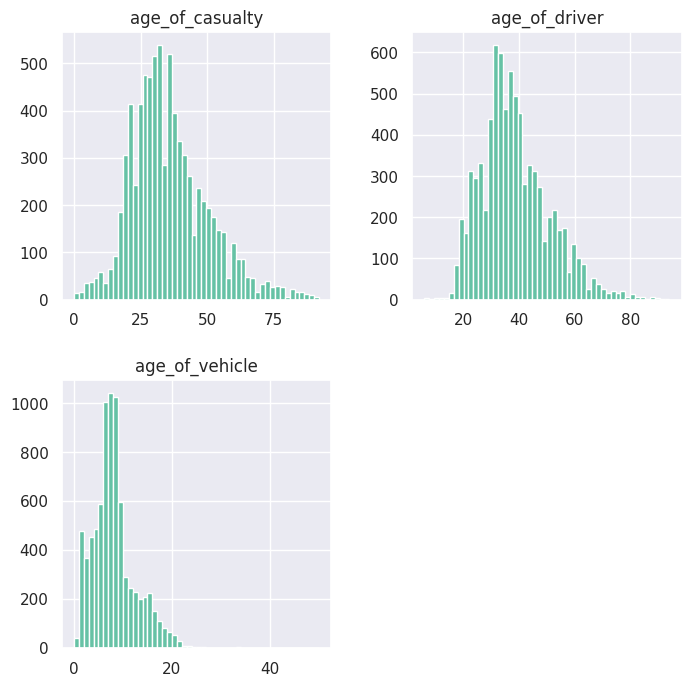

In [234]:
# Display histogram plot of numerical variable
Xtrain[['age_of_casualty','age_of_driver','age_of_vehicle']].hist(bins=50, figsize=(8,8))

The 'age_of vehicle' column is left skewed we shall, we shall be applying log transformation to make it symmetrical in spread.

In [235]:
# Apply natural logarithm transformation to specific columns in the training set (Xtrain) and test set (Xtest)
# Columns include 'age_of_casualty', 'age_of_driver', 'engine_capacity_cc', and 'age_of_vehicle'
for col in ['age_of_vehicle']:
      Xtrain.loc[:, col] = np.log(Xtrain.loc[:, col] + 1)
      Xtest.loc[:, col] = np.log(Xtest.loc[:, col] + 1)

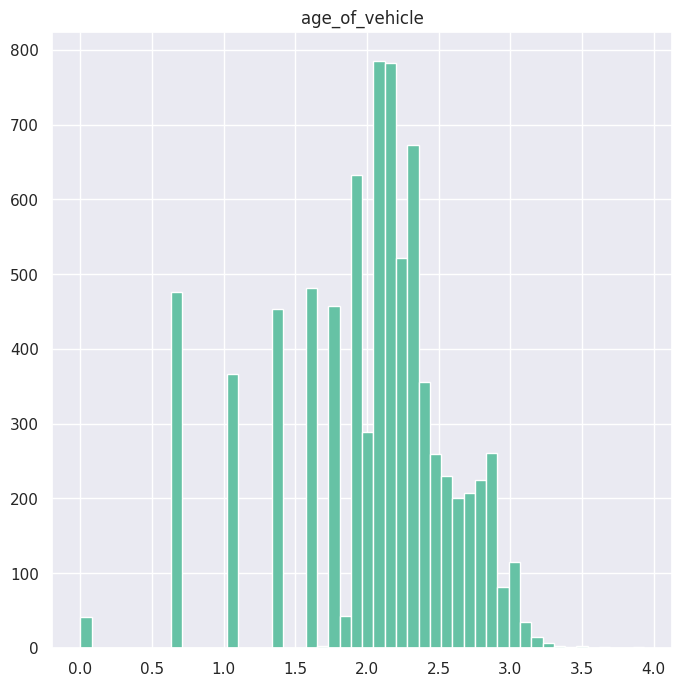

In [236]:
# The histograms of the transformed columns in the training set
_ = Xtrain[['age_of_vehicle']].hist(bins=50, figsize=(8,8))


Age of vehicle becomes more evenly spread out, while before log transformation, the distribution was heavily left-skewed.

In [237]:
# Inspect the shape of Xtrain and Xtest
Xtrain.shape, Xtest.shape


((8000, 135), (2000, 135))

In [238]:
Xtrain.head()

,age_of_driver,age_of_vehicle,age_of_casualty,number_of_vehicles,number_of_casualties,speed_limit,sex_of_driver_Male,sex_of_driver_nan,driver_home_area_type_Small town,driver_home_area_type_Urban area,...,vehicle_manoeuvre_group_Moving off,vehicle_manoeuvre_group_Other,vehicle_manoeuvre_group_Overtaking,vehicle_manoeuvre_group_Parked,vehicle_manoeuvre_group_Reversing,vehicle_manoeuvre_group_Slowing or stopping,vehicle_manoeuvre_group_Turning left,vehicle_manoeuvre_group_Turning right,vehicle_manoeuvre_group_U-turn,vehicle_manoeuvre_group_Waiting
8570,34.285307,2.079442,32.000000,4.000000,1.541969,30.0,0.000000,1.0,0.0,0.004097,...,0.0,0.000000,-0.008975,1.0,0.000000,0.0,0.0,0.0,0.0,0.0
3943,28.000000,2.072205,28.000000,2.000000,1.000000,20.0,0.865188,0.0,0.0,1.004930,...,0.0,1.000000,0.000000,0.0,0.017079,0.0,0.0,0.0,0.0,0.0
9779,43.000000,2.197225,43.000000,2.000000,1.000000,30.0,0.000000,0.0,0.0,1.000000,...,0.0,0.926344,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1766,43.168353,1.609438,35.000000,2.146513,5.000000,20.0,1.000000,0.0,0.0,1.000000,...,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
5085,41.450163,2.072878,38.728837,1.000000,3.000000,30.0,1.000000,0.0,0.0,1.000000,...,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


## **6.6 : OUTLIER DETECTION**

### **ISOLATION FOREST**

In [239]:
# Inspect the shape of Xtrain and Xtest
Xtrain.shape, Xtest.shape


((8000, 135), (2000, 135))

In [240]:
# Create an instance of the IsolationForest class named clf with specified parameters
# Fit the isolation forest model to the training data Xtrain
# Handle missing values by imputing them with the mean of each column
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
Xtrain_imputed = imputer.fit_transform(Xtrain)
clf = IsolationForest(n_estimators=100, random_state=0, contamination=0.05).fit(Xtrain_imputed)
# Predict anomaly scores for each observation in the training data
yhat = clf.predict(Xtrain_imputed)
# Filter the training data based on yhat (Outliers equal to '-1')
Xtrain = Xtrain[yhat != -1]
ytrain = ytrain[yhat != -1]
# Check the dimensions of the filtered Xtrain
Xtrain.shape

(7600, 135)

Around 380 outlers were identified and removed from the Training Dataset

In [241]:
"""Predict test labels with clf, then filter Xtest to keep only instances
predicted as class 1 and adjust ytest accordinglys"""
# Predict anomaly scores for each observation in the testing data
# Impute missing values in Xtest before prediction
Xtest_imputed = imputer.transform(Xtest)  # Use the same imputer fitted on Xtrain
yhat = clf.predict(Xtest_imputed)
# Filter the testing data based on yhat (Outliers equal to '-1')
Xtest = Xtest[yhat == 1]
ytest = ytest[yhat != -1]
# Check the shape of the filtered Xtest
Xtest.shape

(1909, 135)

Around 108 outliers were identified and removed from Testing Dataset

In [242]:
Xtrain = pd.DataFrame(data=Xtrain, columns=Xtrain.columns)
Xtest = pd.DataFrame(data=Xtest, columns=Xtest.columns)

In [243]:
column_names = Xtrain.columns
print("Column names in Xtrain:", column_names)

Column names in Xtrain: Index(['age_of_driver', 'age_of_vehicle', 'age_of_casualty',
       'number_of_vehicles', 'number_of_casualties', 'speed_limit',
       'sex_of_driver_Male', 'sex_of_driver_nan',
       'driver_home_area_type_Small town', 'driver_home_area_type_Urban area',
       ...
       'vehicle_manoeuvre_group_Moving off', 'vehicle_manoeuvre_group_Other',
       'vehicle_manoeuvre_group_Overtaking', 'vehicle_manoeuvre_group_Parked',
       'vehicle_manoeuvre_group_Reversing',
       'vehicle_manoeuvre_group_Slowing or stopping',
       'vehicle_manoeuvre_group_Turning left',
       'vehicle_manoeuvre_group_Turning right',
       'vehicle_manoeuvre_group_U-turn', 'vehicle_manoeuvre_group_Waiting'],
      dtype='object', length=135)


In [244]:
# Display updated trainset
Xtrain.head()

,age_of_driver,age_of_vehicle,age_of_casualty,number_of_vehicles,number_of_casualties,speed_limit,sex_of_driver_Male,sex_of_driver_nan,driver_home_area_type_Small town,driver_home_area_type_Urban area,...,vehicle_manoeuvre_group_Moving off,vehicle_manoeuvre_group_Other,vehicle_manoeuvre_group_Overtaking,vehicle_manoeuvre_group_Parked,vehicle_manoeuvre_group_Reversing,vehicle_manoeuvre_group_Slowing or stopping,vehicle_manoeuvre_group_Turning left,vehicle_manoeuvre_group_Turning right,vehicle_manoeuvre_group_U-turn,vehicle_manoeuvre_group_Waiting
8570,34.285307,2.079442,32.000000,4.000000,1.541969,30.0,0.000000,1.0,0.0,0.004097,...,0.0,0.000000,-0.008975,1.0,0.000000,0.0,0.0,0.0,0.0,0.0
3943,28.000000,2.072205,28.000000,2.000000,1.000000,20.0,0.865188,0.0,0.0,1.004930,...,0.0,1.000000,0.000000,0.0,0.017079,0.0,0.0,0.0,0.0,0.0
9779,43.000000,2.197225,43.000000,2.000000,1.000000,30.0,0.000000,0.0,0.0,1.000000,...,0.0,0.926344,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1766,43.168353,1.609438,35.000000,2.146513,5.000000,20.0,1.000000,0.0,0.0,1.000000,...,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
5085,41.450163,2.072878,38.728837,1.000000,3.000000,30.0,1.000000,0.0,0.0,1.000000,...,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


# **6.7: FEATURE SELECTION**

In [245]:
from sklearn.feature_selection import SelectKBest, f_classif

# Assuming Xtrain and ytrain are already defined and loaded

# Create an instance of SelectKBest to select the top 29 features
selector = SelectKBest(score_func=f_classif, k=29)

# Fit the SelectKBest instance to the training data
Xtrain_selected = selector.fit_transform(Xtrain, ytrain)

# Transform the test data
Xtest_selected = selector.transform(Xtest)

# Get the names of the selected features
selected_features = selector.get_feature_names_out()
print("Selected features:", selected_features)

Selected features: ['age_of_driver' 'age_of_casualty' 'number_of_casualties'
 'sex_of_driver_Male' 'sex_of_driver_nan'
 'driver_home_area_type_Urban area' 'driver_home_area_type_nan'
 'casualty_severity_Serious' 'casualty_severity_Slight'
 'sex_of_casualty_Male' 'sex_of_casualty_nan'
 'pedestrian_location_Crossing on pedestrian crossing facility'
 'pedestrian_location_In carriageway, crossing elsewhere'
 'pedestrian_location_Not a Pedestrian'
 'pedestrian_location_On footway or verge'
 'car_passenger_Not car passenger' 'date_2022-01-22 00:00:00'
 'date_2022-01-23 00:00:00' 'date_2022-01-25 00:00:00'
 'date_2022-01-28 00:00:00' 'date_2022-02-11 00:00:00'
 'date_2022-02-16 00:00:00' 'date_2022-03-13 00:00:00'
 'date_2022-03-20 00:00:00' 'road_surface_conditions_nan'
 'vehicle_manoeuvre_group_Other' 'vehicle_manoeuvre_group_Overtaking'
 'vehicle_manoeuvre_group_Turning right' 'vehicle_manoeuvre_group_U-turn']


In [246]:
"""fit_transform returns a NumPy array, we put it back
into a Pandas dataframe"""
Xtrain = pd.DataFrame(Xtrain, columns=selector.get_feature_names_out())
Xtest = pd.DataFrame(Xtest, columns=selector.get_feature_names_out())

Top 29 features are chosen from Select K method

# **6.8: FEATURE SCALING**

In [247]:
Xtrain.head()

,age_of_driver,age_of_casualty,number_of_casualties,sex_of_driver_Male,sex_of_driver_nan,driver_home_area_type_Urban area,driver_home_area_type_nan,casualty_severity_Serious,casualty_severity_Slight,sex_of_casualty_Male,...,date_2022-01-28 00:00:00,date_2022-02-11 00:00:00,date_2022-02-16 00:00:00,date_2022-03-13 00:00:00,date_2022-03-20 00:00:00,road_surface_conditions_nan,vehicle_manoeuvre_group_Other,vehicle_manoeuvre_group_Overtaking,vehicle_manoeuvre_group_Turning right,vehicle_manoeuvre_group_U-turn
8570,34.285307,32.000000,1.541969,0.000000,1.0,0.004097,1.000000,0.0,1.0,0.0,...,0.005185,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,-0.008975,0.0,0.0
3943,28.000000,28.000000,1.000000,0.865188,0.0,1.004930,0.000000,0.0,1.0,1.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0
9779,43.000000,43.000000,1.000000,0.000000,0.0,1.000000,0.000000,0.0,1.0,0.0,...,0.000000,0.000000,0.0,0.000000,-0.000049,0.000000,0.926344,0.000000,0.0,0.0
1766,43.168353,35.000000,5.000000,1.000000,0.0,1.000000,-0.026194,0.0,1.0,0.0,...,0.000000,0.000000,0.0,0.006075,0.000000,0.000000,1.000000,0.000000,0.0,0.0
5085,41.450163,38.728837,3.000000,1.000000,0.0,1.000000,0.000000,0.0,1.0,1.0,...,0.000000,0.020206,0.0,0.000000,0.000000,0.047993,1.000000,0.000000,0.0,0.0


In [248]:
# Create an instance of StandardScaler
scaler = StandardScaler()
"""fit_transform returns a NumPy array, so we need to put it back
into a Pandas dataframe"""
# Fit and transform the Xtrain
scaled_vals = scaler.fit_transform(Xtrain)
Xtrain = pd.DataFrame(scaled_vals, columns=Xtrain.columns)

# Inspect the Xtrain data
Xtrain.head()

,age_of_driver,age_of_casualty,number_of_casualties,sex_of_driver_Male,sex_of_driver_nan,driver_home_area_type_Urban area,driver_home_area_type_nan,casualty_severity_Serious,casualty_severity_Slight,sex_of_casualty_Male,...,date_2022-01-28 00:00:00,date_2022-02-11 00:00:00,date_2022-02-16 00:00:00,date_2022-03-13 00:00:00,date_2022-03-20 00:00:00,road_surface_conditions_nan,vehicle_manoeuvre_group_Other,vehicle_manoeuvre_group_Overtaking,vehicle_manoeuvre_group_Turning right,vehicle_manoeuvre_group_U-turn
0,-0.339709,-0.267048,0.151772,-1.247053,1.99312,-1.836937,1.930303,-0.330778,0.337418,-1.458349,...,-0.099635,-0.132938,-0.109473,-0.098922,-0.013138,-0.199247,-1.391582,-0.236811,-0.291258,-0.108468
1,-0.848372,-0.542868,-0.454247,0.561426,-0.52115,0.559343,-0.523944,-0.330778,0.337418,0.739035,...,-0.139287,-0.132938,-0.109473,-0.098922,-0.013138,-0.199247,0.755330,-0.186037,-0.291258,-0.108468
2,0.365563,0.491455,-0.454247,-1.247053,-0.52115,0.547540,-0.523944,-0.330778,0.337418,-1.458349,...,-0.139287,-0.132938,-0.109473,-0.098922,-0.017386,-0.199247,0.597197,-0.186037,-0.291258,-0.108468
3,0.379187,-0.060184,4.018470,0.843220,-0.52115,0.547540,-0.588231,-0.330778,0.337418,-1.458349,...,-0.139287,-0.132938,-0.109473,-0.032964,-0.013138,-0.199247,0.755330,-0.186037,-0.291258,-0.108468
4,0.240136,0.196938,1.782112,0.843220,-0.52115,0.547540,-0.523944,-0.330778,0.337418,0.739035,...,-0.139287,0.035390,-0.109473,-0.098922,-0.013138,0.076046,0.755330,-0.186037,-0.291258,-0.108468


In [249]:
# Fit and transform the Xtest
scaled_vals = scaler.transform(Xtest)
# Put it back into a Pandas dataframe
Xtest = pd.DataFrame(scaled_vals, columns=Xtest.columns)
# Inspect the Xtest data
Xtest.head()

,age_of_driver,age_of_casualty,number_of_casualties,sex_of_driver_Male,sex_of_driver_nan,driver_home_area_type_Urban area,driver_home_area_type_nan,casualty_severity_Serious,casualty_severity_Slight,sex_of_casualty_Male,...,date_2022-01-28 00:00:00,date_2022-02-11 00:00:00,date_2022-02-16 00:00:00,date_2022-03-13 00:00:00,date_2022-03-20 00:00:00,road_surface_conditions_nan,vehicle_manoeuvre_group_Other,vehicle_manoeuvre_group_Overtaking,vehicle_manoeuvre_group_Turning right,vehicle_manoeuvre_group_U-turn
0,0.527420,0.629365,-0.454247,-1.247053,-0.52115,0.379017,-0.333356,3.061984,-3.006793,-1.458349,...,-0.139287,-0.132938,-0.109473,-0.098922,0.180665,-0.199247,0.755330,-0.186037,-0.291258,-0.108468
1,0.001475,0.263926,-0.454247,-1.247053,-0.52115,0.547540,-0.523944,-0.330778,0.337418,-1.458349,...,-0.422278,-0.132938,-0.109473,-0.098922,-0.013138,-0.199247,0.755330,-0.186037,-0.291258,-0.108468
2,-1.091159,-0.583175,-0.454247,0.475366,-0.52115,0.547540,-0.523944,-0.330778,0.337418,0.739035,...,-0.139287,-0.117895,-0.109473,-0.098922,-0.013138,-0.199247,-1.391582,-0.186037,3.511862,-0.112407
3,0.527420,0.422500,-0.454247,0.843220,-0.52115,0.547540,-0.523944,3.061984,-3.006793,0.739035,...,-0.139287,-0.132938,-0.109473,-0.098922,-0.013138,-0.199247,-1.391582,-0.186037,-0.291258,-0.108468
4,-0.524656,-0.267048,-0.454247,0.843220,-0.52115,0.547540,-0.523944,-0.332669,0.337418,0.739035,...,-0.139287,-0.132938,-0.109473,-0.098922,-0.013138,-0.199247,0.755330,-0.186037,-0.291258,-0.108468


# **7. CONCLUSION:**

Our study successfully leveraged a comprehensive dataset encompassing driver and casualty demographics, along with vehicle characteristics, to develop a robust predictive model for assessing accident severity. This preprocessed dat was further used for individual predictive model building, this would be helpful in claim handling, insurance premium allocation and overall road safety.

**DATA EXPORTING**

In [250]:
# Put X and y together before exporting
trainset = Xtrain.copy()
trainset["accident_severity"] = ytrain.values
testset = Xtest.copy()
testset["accident_severity"] = ytest.values

In [251]:
# Importing the os module for interacting with the operating system
import os
# Define the directory path
directory = "/content/drive/MyDrive/Colab Notebooks/bigdata"
# Create the directory if it doesn't exist
if not os.path.exists(directory):
  os.makedirs(directory)
# Save the CSV files
trainset.to_csv(os.path.join(directory, "train_set.csv"), index=False)
testset.to_csv(os.path.join(directory, "test_set.csv"), index=False)


The trainset and testset would be used for our individual coursework.